# Risco alimentar e vulnerabilidade social no Brasil

**Pergunta:** quais municípios apresentam maior vulnerabilidade social e risco alimentar?

Esta análise exploratória identifica a sobreposição de três dimensões
por município, utilizando IVS, IDHM, CadInsan e SISVAN.

## 1. Bases de dados

| Base | Referência e população | Obtenção |
|---|---|---|
| IVS e IDHM | 2010; índices municipais | Ipea/PNUD/FJP, via Cozinhas Solidárias |
| CadInsan | Janeiro/2025; famílias do Cadastro Único | MDS, via Cozinhas Solidárias |
| SISVAN — Altura X Idade | 2025; crianças menores de cinco anos acompanhadas | Relatórios públicos do Ministério da Saúde; 27 UFs |
| SISVAN — Peso X Idade | 2025; crianças menores de cinco anos acompanhadas | Relatórios públicos do Ministério da Saúde; 27 UFs |
| Malha municipal | Ano não informado; apoio aos mapas | API de malhas v4 do IBGE |

As bases sociais vêm de [Cozinhas Solidárias](https://github.com/TriangulosTecnologia/cozsolidarias);
as nutricionais, de coleta nos [relatórios públicos SISVAN](https://sisaps.saude.gov.br/sisvan/relatoriopublico/).

## 2. Indicadores e critérios

| Dimensão | Indicadores e significado | Critério principal |
|---|---|---|
| Social | IVS: vulnerabilidade social; IDHM: índice de desenvolvimento humano municipal | IVS ≥0,401 **e** IDHM <0,600 |
| Alimentar | CadInsan: percentual de famílias com risco estimado de insegurança alimentar grave | CadInsan ≥P75 nacional, cenário `com_PBF` |
| Nutricional | DAI: déficit de altura para idade; DPI: déficit de peso para idade | DAI ≥6,7% **e** DPI ≥1,8%; ≥20 avaliações em **cada** relatório |

Os cortes sociais correspondem às faixas alta/muito alta do IVS e baixa/muito
baixa do IDHM. Os cortes nutricionais e o mínimo de avaliações foram adaptados
do [Mapa InSAN, p. 11, tabela 2](https://aplicacoes.mds.gov.br/fomento-questionario/pdf/MapaInSAN_20172022.pdf#page=11).
Os percentuais vêm das prevalências nacionais da PNDS 2006.

**P75** identifica o quartil superior dos municípios; é uma escolha exploratória,
não um corte oficial. O cenário `com_PBF` considera o efeito do Bolsa Família
na renda, não um grupo exclusivo de beneficiários.

O Mapa InSAN analisa crianças acompanhadas pelo PBF e utiliza agrupamento
estatístico. Aqui o público SISVAN é mais amplo e a análise é de sobreposição,
não uma reprodução desse mapeamento.

Os parâmetros abaixo permitem alterar os critérios e executar novamente.

In [1]:
QUANTIL_CADINSAN = 0.75
CORTE_DAI = 6.7 
CORTE_DPI = 1.8  
MINIMO_AVALIADOS = 20
CENARIO_CADINSAN = "com_PBF"
QUANTIS_SENSIBILIDADE = [0.70, 0.75, 0.80, 0.90]
MINIMOS_SENSIBILIDADE = [20, 50, 100]
CORTES_DAI_SENSIBILIDADE = [6.7, 10.0, "P75"]
CENARIOS_SENSIBILIDADE = ["com_PBF", "sem_PBF"]
GERAR_MAPAS = True
BAIXAR_RESULTADOS_NO_COLAB = False

### Preparação do ambiente

Execute também as células técnicas recolhidas: elas preparam as bibliotecas,
as entradas e as funções de análise. As tabelas usam formatação brasileira;
`—` indica ausência. Essa formatação não altera os valores.

In [2]:
import importlib.util
import subprocess
import sys
from pathlib import Path

packages = {"pandas": "pandas>=2.2,<4", "numpy": "numpy>=1.26,<3",
            "matplotlib": "matplotlib>=3.8,<4", "scipy": "scipy>=1.11,<2",
            "jinja2": "jinja2>=3.1,<4"}
missing = [requirement for module, requirement in packages.items()
           if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

import hashlib
import io
import json
import zipfile
import base64
import platform
import shutil
from datetime import datetime, timezone
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import scipy
from IPython.display import display, Markdown

PASTA_EXECUCAO = Path("resultados")
PASTA_DADOS = PASTA_EXECUCAO / "entradas"
PASTA_SAIDA = PASTA_EXECUCAO / "resultados"
PASTA_FIGURAS = PASTA_SAIDA / "figuras"
PASTA_SAIDA.mkdir(parents=True, exist_ok=True)
PASTA_FIGURAS.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_columns", 30)

"""Formatação brasileira de tabelas; ferramenta local de manutenção."""

import pandas as pd
from pandas.api.types import is_bool_dtype, is_integer_dtype, is_numeric_dtype


COLUNAS_CONTAGEM = {
    "municipios", "registros_origem", "municipios_na_uniao",
    "correspondencias_sisvan", "sisvan_sem_fonte", "fonte_sem_sisvan",
    "numerador", "denominador", "municipios_referencia", "municipios_no_criterio",
    "percentil", "elegiveis", "coincidentes_principal",
    "minimo_avaliados", "cenarios_elegiveis", "cenarios_selecionado", "cenarios_testados",
    "familias_cadinsan", "convergencia_total", "entram_vs_principal", "saem_vs_principal",
    "municipios_dim_alimentar", "municipios_dim_nutricional",
}


def numero_br(valor, casas=3):
    if pd.isna(valor):
        return "—"
    return f"{valor:,.{casas}f}".translate(str.maketrans({",": ".", ".": ","}))


def contagem_br(valor):
    return numero_br(valor, 0)


def percentual_br(valor):
    return "—" if pd.isna(valor) else numero_br(valor, 2) + "%"


def quantil_br(valor):
    return numero_br(valor, 2)


def tabela_br(tabela):
    """Retorna apenas um Styler; mantém valores, tipos, índices e colunas.

    Percentuais já estão na escala 0–100. Não multiplica razões por 100,
    não converte códigos em números e não muda contagens na base exportada.
    """
    formatos = {}
    for coluna in tabela.columns:
        nome = str(coluna).lower()
        if is_bool_dtype(tabela[coluna]):
            continue
        if nome in COLUNAS_CONTAGEM or nome.endswith("_n") or nome.startswith(
            ("avaliados_", "pessoas ", "famílias ", "avaliações ")
        ):
            formatos[coluna] = contagem_br
        elif "(%)" in nome or "_pct" in nome or nome.startswith("pct_") or nome == "percentual_agregado":
            formatos[coluna] = percentual_br
        elif nome == "quantil":
            formatos[coluna] = quantil_br
        elif is_numeric_dtype(tabela[coluna]):
            formatos[coluna] = contagem_br if is_integer_dtype(tabela[coluna]) else numero_br
    visualizacao = tabela.style.format(formatos, na_rep="—", escape="html")
    # O corte combina índices (0–1) e percentuais (0–100) na mesma coluna.
    if {"indicador", "corte"}.issubset(tabela.columns):
        indices = tabela.index[tabela["indicador"].isin(["ivs", "idhm"])]
        percentuais = tabela.index[tabela["indicador"].isin(["cadinsan", "dai", "dpi"])]
        if len(indices):
            visualizacao.format(numero_br, subset=(indices, ["corte"]), na_rep="—")
        if len(percentuais):
            visualizacao.format(percentual_br, subset=(percentuais, ["corte"]), na_rep="—")
    return visualizacao

CODIGO_ANALISE_SHA256 = "24cda636ee7b6746b2fea20400973458aca0ccd99ca3f3eedbb9acc2cd202d57"

VERSOES_REFERENCIA = {'pandas': '3.0.5', 'numpy': '2.5.3', 'matplotlib': '3.11.2', 'scipy': '1.18.1', 'Jinja2': '3.1.6'}
from importlib.metadata import version as versao_instalada
divergencias_ambiente = {nome: {"referencia": valor, "execucao": versao_instalada(nome)}
    for nome, valor in VERSOES_REFERENCIA.items() if versao_instalada(nome) != valor}
if divergencias_ambiente or platform.python_version() != "3.13.12":
    print("Ambiente diferente da referência Python 3.13.12; consultar o manifesto da execução.")
    print(divergencias_ambiente)

In [3]:
# @title Bases e malha incorporadas — executar sem editar
PACOTE_BASE64 = "..."
with zipfile.ZipFile(io.BytesIO(base64.b64decode(PACOTE_BASE64))) as pacote:
    for membro in pacote.infolist():
        destino = (PASTA_DADOS / membro.filename).resolve()
        if not destino.is_relative_to(PASTA_DADOS.resolve()):
            raise ValueError("Caminho inválido no pacote de dados")
    pacote.extractall(PASTA_DADOS)
print("Bases recuperadas para análise.")

Bases recuperadas para análise.


In [4]:
# @title Funções de análise — executar sem editar
"""Convergência social, alimentar e nutricional combinada DAI + DPI."""

from __future__ import annotations

import hashlib
import json
from itertools import product
from pathlib import Path

import numpy as np
import pandas as pd

from decimal import Decimal, InvalidOperation

UF_REGIONS = {
    "11": ("RO", "Norte"), "12": ("AC", "Norte"),
    "13": ("AM", "Norte"), "14": ("RR", "Norte"),
    "15": ("PA", "Norte"), "16": ("AP", "Norte"),
    "17": ("TO", "Norte"), "21": ("MA", "Nordeste"),
    "22": ("PI", "Nordeste"), "23": ("CE", "Nordeste"),
    "24": ("RN", "Nordeste"), "25": ("PB", "Nordeste"),
    "26": ("PE", "Nordeste"), "27": ("AL", "Nordeste"),
    "28": ("SE", "Nordeste"), "29": ("BA", "Nordeste"),
    "31": ("MG", "Sudeste"), "32": ("ES", "Sudeste"),
    "33": ("RJ", "Sudeste"), "35": ("SP", "Sudeste"),
    "41": ("PR", "Sul"), "42": ("SC", "Sul"), "43": ("RS", "Sul"),
    "50": ("MS", "Centro-Oeste"), "51": ("MT", "Centro-Oeste"),
    "52": ("GO", "Centro-Oeste"), "53": ("DF", "Centro-Oeste"),
}

def numeric(values, label):
    """Lê ponto/vírgula decimal e %, sem converter ausência em zero."""
    clean = values.astype("string").str.strip()
    clean = clean.str.replace("%", "", regex=False).str.replace(",", ".", regex=False)
    present = clean.notna() & clean.ne("")
    result = pd.to_numeric(clean.mask(~present), errors="coerce").astype(float)
    invalid = present & result.isna()
    if invalid.any():
        raise ValueError(f"Valores não numéricos em {label}: {values[invalid].head().tolist()}")
    if not np.isfinite(result.dropna()).all():
        raise ValueError(f"Valores infinitos em {label}")
    return result

def codes(values, length, source):
    result = values.astype("string").str.strip()
    if not result.str.fullmatch(rf"\d{{{length}}}").fillna(False).all():
        raise ValueError(f"{source}: códigos devem ter {length} dígitos.")
    if result.duplicated().any():
        raise ValueError(f"{source}: código municipal duplicado.")
    return result

def check_range(values, low, high, label):
    if not values.dropna().between(low, high).all():
        raise ValueError(f"{label}: valores fora de [{low}, {high}].")

def interpret_sisvan_counts(values, percentages, code):
    """Interpreta artefatos numéricos sem modificar as células de entrada.

    Decimais do XLSX são interpretados como milhares. Apenas quando a soma
    ou os percentuais não conferem, tenta conciliar células truncadas pelo
    exportador.
    """
    original_values, initial, integral = [], [], []
    for raw in values:
        text = str(raw).strip()
        try:
            value = Decimal(text)
        except InvalidOperation as exc:
            raise ValueError(f"{code}: contagem SISVAN não numérica: {raw!r}") from exc
        if not value.is_finite() or value < 0:
            raise ValueError(f"{code}: contagem SISVAN inválida: {raw!r}")
        original_values.append(value)
        if value == value.to_integral_value():
            initial.append(int(value))
            integral.append(True)
        else:
            scaled = value * 1000
            if scaled != scaled.to_integral_value():
                raise ValueError(f"{code}: escala decimal SISVAN irresolvível: {raw!r}")
            initial.append(int(scaled))
            integral.append(False)
    pcts = []
    for raw in percentages:
        text = str(raw).strip()
        pct = 0.0 if text in {"-", "–", "—"} else float(text.rstrip("%").replace(",", "."))
        if not np.isfinite(pct) or not 0 <= pct <= 100:
            raise ValueError(f"{code}: percentual SISVAN inválido: {raw!r}")
        pcts.append(pct)

    def consistent(counts, total):
        if sum(counts) != total:
            return False
        if total == 0:
            return not any(pcts)
        return all(abs(n / total * 100 - pct) <= 0.011 for n, pct in zip(counts, pcts))

    # Mantém as contagens inteiras quando soma e percentuais conferem.
    if consistent(initial[:-1], initial[-1]):
        changed = any(value != n for value, n in zip(original_values, initial))
        return tuple(initial), changed, 1

    # Exportações podem perder zeros finais (ex.: 1.000 vira 1). Essa leitura
    # só é tentada para linhas inconsistentes, não para criar outra população.
    candidates = [[n, n * 1000] if is_int and n else [n]
                  for n, is_int in zip(initial, integral)]
    solutions = []
    for counts in product(*candidates[:-1]):
        total = sum(counts)
        if total not in candidates[-1]:
            continue
        if not consistent(counts, total):
            continue
        solutions.append((*counts, total))
    if not solutions:
        raise ValueError(f"{code}: contagens não conciliam soma e percentuais oficiais.")
    if len(solutions) != 1:
        raise ValueError(f"{code}: contagens inconsistentes admitem mais de uma interpretação; conferir na fonte.")
    chosen = solutions[0]
    changed = any(value != n for value, n in zip(original_values, chosen))
    return chosen, changed, 1

def figure_style():
    import matplotlib.pyplot as plt
    plt.rcParams.update({"font.size": 10, "axes.spines.top": False,
                         "axes.spines.right": False, "figure.dpi": 110,
                         "savefig.dpi": 180})

def save_figure(fig, output, name):
    output = Path(output)
    output.mkdir(parents=True, exist_ok=True)
    fig.savefig(output / f"{name}.png", bbox_inches="tight")
    fig.savefig(output / f"{name}.svg", bbox_inches="tight")

def geometry_audit(geojson, base):
    features = geojson["features"]
    codes_7 = pd.Series([str(f["properties"]["codarea"]) for f in features], dtype="string")
    codes(codes_7, 7, "Malha IBGE")
    prefixes = codes_7.str[:6]
    if prefixes.duplicated().any():
        raise ValueError("Malha com prefixos municipais duplicados.")
    existing = dict(zip(prefixes, codes_7))
    known = base["codigo_ibge_7"].notna()
    for row in base.loc[known].itertuples():
        if row.codigo_ibge_6 in existing and existing[row.codigo_ibge_6] != row.codigo_ibge_7:
            raise ValueError("Conflito de código municipal entre malha e bases sociais.")
    return pd.DataFrame({"codigo_ibge_6": base["codigo_ibge_6"],
                         "codigo_ibge_7_malha": base["codigo_ibge_6"].map(existing),
                         "tem_geometria": base["codigo_ibge_6"].isin(existing)})

def map_figure(geojson, result, column, title, output, filename, categories=None):
    """Mapa ilustrativo em coordenadas geográficas; anéis interiores preservados."""
    from textwrap import fill
    import matplotlib.pyplot as plt
    from matplotlib.collections import PatchCollection
    from matplotlib.colors import Normalize
    from matplotlib.path import Path as MplPath
    from matplotlib.patches import Patch, PathPatch
    lookup = result.set_index("codigo_ibge_6")[column].to_dict()
    patches, values, colors = [], [], []
    for feature in geojson["features"]:
        geometry = feature["geometry"]
        polygons = ([geometry["coordinates"]] if geometry["type"] == "Polygon"
                    else geometry["coordinates"])
        value = lookup.get(str(feature["properties"]["codarea"])[:6], np.nan)
        for polygon in polygons:
            vertices, commands = [], []
            for ring in polygon:
                coordinates = np.asarray(ring, dtype=float)[:, :2]
                if len(coordinates) < 4:
                    continue
                vertices.extend(coordinates)
                commands.extend([MplPath.MOVETO] + [MplPath.LINETO] * (len(coordinates) - 2) + [MplPath.CLOSEPOLY])
            if vertices:
                patches.append(PathPatch(MplPath(vertices, commands)))
                if categories is not None:
                    colors.append(categories.get(value, "#b9b9b9"))
                else:
                    values.append(float(value) if pd.notna(value) else np.nan)
    fig, ax = plt.subplots(figsize=(9, 9))
    collection = PatchCollection(patches, linewidths=0.08, edgecolors="#ffffff")
    if categories is not None:
        collection.set_facecolors(colors)
        ax.legend(handles=[Patch(facecolor=color, label=fill(label, width=42)) for label, color in categories.items()],
                  loc="lower left", fontsize=8, frameon=False)
    else:
        arr = np.ma.masked_invalid(values)
        collection.set_array(arr)
        cmap = plt.get_cmap("YlOrRd_r" if column == "idhm" else "YlOrRd").copy()
        cmap.set_bad("#b9b9b9")
        collection.set_cmap(cmap)
        finite = np.asarray(values)[np.isfinite(values)]
        if finite.size:
            collection.set_norm(Normalize(vmin=float(finite.min()), vmax=float(finite.max())))
        fig.colorbar(collection, ax=ax, fraction=0.035, pad=0.015)
        ax.legend(handles=[Patch(facecolor="#b9b9b9", label="Ausente / não elegível")],
                  loc="lower left", frameon=False)
    ax.add_collection(collection)
    ax.set(xlim=(-74.5, -32), ylim=(-34.5, 6), title=title)
    ax.set_aspect("equal")
    ax.axis("off")
    fig.text(0.15, 0.075, "IBGE: malha simplificada de apoio; coordenadas geográficas.\n"
             "Mapa ilustrativo; não mede cobertura ou concentração espacial estatística.", fontsize=8)
    save_figure(fig, output, filename)
    return fig

DATA_FILES = {
    "ivs_idhm": "ivs_idhm/atlasivs_municipios_2010.csv",
    "cadinsan": "cadinsan/CADINSAN_2025_dados_municipais.csv",
    "sisvan_altura": "sisvan/sisvan_municipios_altura_por_idade_0_a_menor_5_anos_2025.csv",
    "sisvan_peso": "sisvan/sisvan_municipios_peso_por_idade_0_a_menor_5_anos_2025.csv",
}
CATALOGUE_DATASETS = {"ivs_idhm": "municipios_ivs", "cadinsan": "municipios_cadinsan"}
SUPPORT_FILES = (
    "sisvan/sisvan_municipios_altura_por_idade_0_a_menor_5_anos_2025.metadados.json",
    "sisvan/sisvan_municipios_peso_por_idade_0_a_menor_5_anos_2025.metadados.json",
    "apoio/ibge/malha_municipal_simplificada.geojson",
    "apoio/ibge/malha_municipal_simplificada.metadados.json",
    "documentacao/dataset_catalogue.json",
    "documentacao/dataset_catalogue_original.json",
    "documentacao/manifesto_entradas.json",
)
FIXED_CUTS = {"ivs": (0.401, ">="), "idhm": (0.600, "<")}
DIMENSIONS = ["dim_social", "dim_alimentar", "dim_nutricional"]
CONVERGENCE_LABELS = {
    0: "Sem convergência pelos critérios adotados",
    1: "Convergência em uma dimensão",
    2: "Convergência em duas dimensões",
    3: "Convergência nas três dimensões",
}
OMS_LABELS = ["muito baixa", "baixa", "média", "alta", "muito alta"]
OMS_COLORS = dict(zip(OMS_LABELS, ["#eff3ff", "#bdd7e7", "#fdcc8a", "#fc8d59", "#b30000"]))
OMS_COLORS["dados insuficientes"] = "#b9b9b9"
DIMENSION_COLORS = {"0": "#e0eee7", "1": "#fdd49e", "2": "#fc8d59",
                    "3": "#9e1b32", "dados insuficientes": "#b9b9b9"}


def verify_hashes(directory):
    directory = Path(directory)
    records = []
    for line in (directory / "SHA256SUMS").read_text().splitlines():
        if not line.strip():
            continue
        expected, relative = line.split(maxsplit=1)
        relative = relative.lstrip("*")
        path = (directory / relative).resolve()
        if not path.is_relative_to(directory.resolve()):
            raise ValueError(f"Caminho inválido no manifesto: {relative}")
        actual = hashlib.sha256(path.read_bytes()).hexdigest()
        if actual != expected:
            raise ValueError(f"Integridade inválida: {relative}")
        records.append({"arquivo": relative, "sha256": actual, "integridade": "OK"})
    required = set(DATA_FILES.values()) | set(SUPPORT_FILES)
    if len(records) != len(required) or {r["arquivo"] for r in records} != required:
        raise ValueError("O manifesto deve identificar as quatro bases e todos os arquivos de apoio.")
    # A tabela de fontes analíticas continua contendo somente os quatro CSVs.
    return pd.DataFrame([r for r in records if r["arquivo"] in DATA_FILES.values()])


def validate_catalogue(catalogue_path, directory):
    raw = Path(catalogue_path).read_bytes()
    catalogue = json.loads(raw.decode("utf-8-sig"))
    records = []
    for source, dataset_id in CATALOGUE_DATASETS.items():
        dataset = catalogue["datasets"][dataset_id]
        relative = DATA_FILES[source]
        actual = hashlib.sha256((Path(directory) / relative).read_bytes()).hexdigest()
        if actual != dataset["stats"]["checkSum"].removeprefix("sha256:"):
            raise ValueError(f"Catálogo não corresponde a {relative}")
        temporal = dataset["temporal"]["extent"][0]
        records.append({"dataset_id": dataset_id, "arquivo": relative, "titulo": dataset["title"],
                        "inicio_referencia_catalogo": temporal[0], "fim_referencia_catalogo": temporal[1],
                        "fonte_original": dataset["source"]["url"], "sha256": actual,
                        "corresponde_ao_catalogo": True})
    return pd.DataFrame(records), {"catalogo_sha256": hashlib.sha256(raw).hexdigest(),
                                   "catalogo_id": catalogue["catalog"]["id"],
                                   "fontes": records, "recorte": "Somente fontes sociais usadas no experimento"}


def sisvan_metadata(directory, source):
    path = Path(directory) / DATA_FILES[source]
    metadata = json.loads(path.with_suffix(".metadados.json").read_text())
    index = "altura_por_idade" if source == "sisvan_altura" else "peso_por_idade"
    expected = {"ano": 2025, "fase": "crianca", "indice": index,
                "faixa_etaria": "0_a_menor_5_anos", "nu_idade_inicio": "0", "nu_idade_fim": "5"}
    if any(metadata.get(key) != value for key, value in expected.items()):
        raise ValueError(f"{source}: recorte incompatível com menores de cinco anos, 2025")
    if metadata.get("indicadores_derivados", []) != []:
        raise ValueError("A entrada nutricional não deve conter DAI ou DPI pré-calculado")
    if "sha256_csv" in metadata and metadata["sha256_csv"] != hashlib.sha256(path.read_bytes()).hexdigest():
        raise ValueError(f"{source}: hash incompatível com os metadados")
    if set(metadata["ufs"]) != {uf for uf, _ in UF_REGIONS.values()}:
        raise ValueError(f"{source}: coleta nacional incompleta")
    return metadata


def read_nutrition(directory, source):
    metadata = sisvan_metadata(directory, source)
    raw = pd.read_csv(Path(directory) / DATA_FILES[source], dtype="string",
                      encoding="utf-8-sig", keep_default_na=False)
    if list(raw.columns) != metadata["colunas"] or len(raw) != metadata["linhas"]:
        raise ValueError(f"{source}: esquema ou linhas incompatíveis com os metadados")
    height = source == "sisvan_altura"
    parts = (["Altura Muito Baixa para a Idade", "Altura Baixa para a Idade",
              "Altura Adequada para a Idade"] if height else
             ["Peso Muito Baixo para a Idade", "Peso Baixo para a Idade",
              "Peso Adequado ou Eutrófico", "Peso Elevado para a Idade"])
    names = (["altura_muito_baixa_n", "altura_baixa_n", "altura_adequada_n"] if height else
             ["peso_muito_baixo_n", "peso_baixo_n", "peso_adequado_n", "peso_elevado_n"])
    total = "avaliados_altura" if height else "avaliados_peso"
    count_columns = [p + " - Quantidade" for p in parts] + ["Total"]
    pct_columns = [p + " - %" for p in parts]
    interpreted = [interpret_sisvan_counts([row[c] for c in count_columns],
                    [row[c] for c in pct_columns], row["Código IBGE"]) for _, row in raw.iterrows()]
    table = pd.DataFrame({f"codigo_{source}_original": codes(raw["Código IBGE"], 6, source),
                          f"municipio_{source}": raw["Município"], f"uf_{source}": raw["UF"],
                          f"ano_{source}": metadata["ano"]})
    for i, name in enumerate(names + [total]):
        table[name] = [v[0][i] for v in interpreted]
        table[name + "_valor_fonte"] = raw[count_columns[i]]
    for column, name in zip(pct_columns, names):
        table[name + "_percentual_fonte"] = raw[column]
    table[f"{source}_escala_alterada"] = [v[1] for v in interpreted]
    table[f"{source}_escalas_compativeis"] = [v[2] for v in interpreted]
    if not table[names].sum(axis=1).eq(table[total]).all():
        raise ValueError(f"{source}: soma das categorias difere do total")
    indicator = "dai" if height else "dpi"
    table[indicator + "_n"] = table[names[:2]].sum(axis=1, min_count=2)
    table[indicator + "_pct"] = table[indicator + "_n"].div(table[total].where(table[total] > 0)) * 100
    check_range(table[indicator + "_pct"], 0, 100, indicator)
    return table


def prepare_base(directory):
    directory = Path(directory)
    hashes = verify_hashes(directory)
    ivs = pd.read_csv(directory / DATA_FILES["ivs_idhm"], dtype="string", keep_default_na=False)
    tables = {"ivs_idhm": pd.DataFrame({"codigo_ivs_original": codes(ivs["municipio"], 7, "IVS/IDHM"),
                                        "municipio_ivs": ivs["nome_municipio_uf"]})}
    for column in ivs.columns:
        if column not in ("municipio", "nome_municipio_uf"):
            tables["ivs_idhm"][column] = numeric(ivs[column], column)
            check_range(tables["ivs_idhm"][column], 0, 1, column)
    ci = pd.read_csv(directory / DATA_FILES["cadinsan"], dtype="string", keep_default_na=False)
    tables["cadinsan"] = pd.DataFrame({"codigo_cadinsan_original": codes(ci["Cod_IBGE"], 7, "CadInsan"),
                                      "municipio_cadinsan": ci["Município"]})
    # Este campo pertence ao próprio CSV CadInsan: é seu denominador de famílias.
    tables["cadinsan"]["familias_cadinsan"] = numeric(ci["Cadastros_Cadunico"], "famílias CadInsan")
    for scenario in ("com_PBF", "sem_PBF"):
        for original, name in [(f"Cadinsan_absoluto_{scenario}", f"cadinsan_n_{scenario}"),
                               (f"Cadinsan_proporcional_{scenario}", f"cadinsan_pct_{scenario}_arquivo")]:
            tables["cadinsan"][name] = numeric(ci[original], original)
    for source in ("sisvan_altura", "sisvan_peso"):
        tables[source] = read_nutrition(directory, source)
    for source, table in tables.items():
        original = next(c for c in table if c.startswith("codigo_"))
        table["codigo_ibge_6"] = table[original].str[:6]
        if table["codigo_ibge_6"].duplicated().any():
            raise ValueError(f"{source}: prefixos municipais duplicados")
        table[f"tem_{source}"] = True
    base = tables["sisvan_altura"]
    for source in ("sisvan_peso", "ivs_idhm", "cadinsan"):
        base = base.merge(tables[source], on="codigo_ibge_6", how="outer", validate="one_to_one")
    for source in tables:
        base[f"tem_{source}"] = base[f"tem_{source}"].fillna(False).astype(bool)
    original_7 = ["codigo_cadinsan_original", "codigo_ivs_original"]
    base["codigo_ibge_7"] = base[original_7].bfill(axis=1).iloc[:, 0]
    for column in original_7:
        if (base[column].notna() & base["codigo_ibge_7"].ne(base[column])).any():
            raise ValueError("Conflito entre códigos das fontes sociais")
    # Na ausência de código de sete dígitos, o prefixo original é explicitamente mantido.
    base["codigo_ibge"] = base["codigo_ibge_7"].fillna(base["codigo_ibge_6"])
    base["municipio"] = base[["municipio_sisvan_altura", "municipio_sisvan_peso",
                              "municipio_cadinsan", "municipio_ivs"]].bfill(axis=1).iloc[:, 0]
    base["uf"] = base["codigo_ibge_6"].str[:2].map(lambda c: UF_REGIONS[c][0])
    base["regiao"] = base["codigo_ibge_6"].str[:2].map(lambda c: UF_REGIONS[c][1])
    for source in ("sisvan_altura", "sisvan_peso"):
        present = base[f"tem_{source}"]
        if base.loc[present, "uf"].ne(base.loc[present, f"uf_{source}"]).any():
            raise ValueError(f"{source}: UF incompatível com código municipal")
    counts = [c for c in base if c.endswith("_n") or c.startswith("avaliados_") and not c.endswith("_fonte")]
    counts += ["familias_cadinsan", "cadinsan_n_com_PBF", "cadinsan_n_sem_PBF"]
    for column in counts:
        values = base[column].dropna()
        if (values < 0).any() or not np.isclose(values % 1, 0).all():
            raise ValueError(f"{column}: contagem negativa ou não inteira")
    for scenario in ("com_PBF", "sem_PBF"):
        absolute, denominator = base[f"cadinsan_n_{scenario}"], base["familias_cadinsan"]
        if (absolute > denominator).fillna(False).any():
            raise ValueError("CadInsan absoluto excede denominador")
        calculated = absolute.div(denominator.where(denominator > 0)) * 100
        reported = base[f"cadinsan_pct_{scenario}_arquivo"]
        check_range(reported, 0, 100, "CadInsan na fonte")
        complete = calculated.notna() & reported.notna()
        if not np.allclose(calculated[complete], reported[complete], atol=0.11):
            raise ValueError("Percentual CadInsan diverge da razão no arquivo")
        base[f"cadinsan_pct_{scenario}"] = calculated
        base[f"cadinsan_diferenca_pp_{scenario}"] = calculated - reported
        check_range(calculated, 0, 100, "CadInsan recalculado")
    base["cadinsan_referencia"] = "2025-01"
    height = base["tem_sisvan_altura"]
    audit = pd.DataFrame([{"fonte": source, "registros_origem": len(table),
                          "municipios_na_uniao": len(base),
                          "correspondencias_sisvan": int((base[f"tem_{source}"] & height).sum()),
                          "sisvan_sem_fonte": int((height & ~base[f"tem_{source}"]).sum()),
                          "fonte_sem_sisvan": int((~height & base[f"tem_{source}"]).sum())}
                         for source, table in tables.items()])
    return base.sort_values("codigo_ibge_6").reset_index(drop=True), audit, hashes


def nullable_flag(values, valid, cutoff, operator=">="):
    flag = pd.Series(pd.NA, index=values.index, dtype="boolean")
    comparison = values.ge(cutoff) if operator == ">=" else values.lt(cutoff)
    flag.loc[valid] = comparison.loc[valid]
    return flag


def classify(base, quantile=0.75, min_evaluated=20, scenario="com_PBF", dai_cutoff=6.7, dpi_cutoff=1.8):
    if not 0 < quantile < 1 or not isinstance(min_evaluated, int) or min_evaluated < 1:
        raise ValueError("Quantil deve estar entre 0 e 1; mínimo deve ser inteiro positivo")
    if scenario not in ("com_PBF", "sem_PBF"):
        raise ValueError("Cenário inválido")
    if not np.isfinite(dpi_cutoff) or not 0 <= dpi_cutoff <= 100:
        raise ValueError("Corte DPI deve ser percentual entre 0 e 100")
    result = base.copy()
    result["cadinsan_pct"] = result[f"cadinsan_pct_{scenario}"]
    result["cadinsan_pct_arquivo"] = result[f"cadinsan_pct_{scenario}_arquivo"]
    result["cadinsan_n"] = result[f"cadinsan_n_{scenario}"]
    valid_ci = result["cadinsan_pct"].notna() & result["familias_cadinsan"].gt(0)
    valid_height = result["dai_pct"].notna() & result["avaliados_altura"].ge(min_evaluated)
    valid_weight = result["dpi_pct"].notna() & result["avaliados_peso"].ge(min_evaluated)
    if not valid_ci.any():
        raise ValueError("Nenhum município válido para quantil CadInsan")
    ci_cut = result.loc[valid_ci, "cadinsan_pct"].quantile(quantile)
    if dai_cutoff == "P75":
        if not valid_height.any():
            raise ValueError("Nenhum município válido para quantil DAI")
        height_cut = result.loc[valid_height, "dai_pct"].quantile(0.75)
        dai_method = "quantil exploratório"
    else:
        height_cut, dai_method = float(dai_cutoff), "referência Mapa InSAN" if float(dai_cutoff) == 6.7 else "referência OMS"
        if not np.isfinite(height_cut) or not 0 <= height_cut <= 100:
            raise ValueError("Corte DAI deve ser percentual entre 0 e 100")
    specs = [("ivs", "ivs", result["ivs"].notna(), 0.401, ">=", "faixa IVS/Ipea"),
             ("idhm", "idhm", result["idhm"].notna(), 0.600, "<", "baixo desenvolvimento adotado"),
             ("cadinsan", "cadinsan_pct", valid_ci, ci_cut, ">=", "quantil exploratório"),
             ("dai", "dai_pct", valid_height, height_cut, ">=", dai_method),
             ("dpi", "dpi_pct", valid_weight, dpi_cutoff, ">=", "referência Mapa InSAN")]
    cuts = []
    for label, column, valid, cutoff, operator, method in specs:
        result[f"criterio_{label}"] = nullable_flag(result[column], valid, cutoff, operator)
        cuts.append({"indicador": label, "corte": float(cutoff), "operador": operator,
                     "metodo": method, "municipios_referencia": int(valid.sum()),
                     "municipios_no_criterio": int(result[f"criterio_{label}"].sum()),
                     "percentil": quantile * 100 if label == "cadinsan" else 75 if label == "dai" and dai_cutoff == "P75" else None})
    # Mesmo com um critério conhecido desfavorável, falta de outro impede a dimensão social.
    valid_social = result[["criterio_ivs", "criterio_idhm"]].notna().all(axis=1)
    result["dim_social"] = (result["criterio_ivs"] & result["criterio_idhm"]).where(valid_social)
    result["dim_alimentar"] = result["criterio_cadinsan"]
    both_valid = valid_height & valid_weight
    result["dim_nutricional"] = (result["criterio_dai"] & result["criterio_dpi"]).where(both_valid)
    result["social_alta"] = result["dim_social"]
    result["cadinsan_alto"] = result["dim_alimentar"]
    result["nutricional_alta"] = result["dim_nutricional"]
    result["social_status"] = "dados insuficientes"
    for ivs_flag, idhm_flag, label in [(True, True, "ambos desfavoráveis"),
                                     (True, False, "apenas IVS desfavorável"),
                                     (False, True, "apenas IDHM desfavorável"),
                                     (False, False, "nenhum desfavorável")]:
        mask = valid_social & result["criterio_ivs"].eq(ivs_flag) & result["criterio_idhm"].eq(idhm_flag)
        result.loc[mask.fillna(False), "social_status"] = label
    result["elegivel_principal"] = result[DIMENSIONS].notna().all(axis=1)
    result["n_dimensoes_desfavoraveis"] = result[DIMENSIONS].sum(axis=1).where(result["elegivel_principal"]).astype("Int64")
    result["convergencia_total"] = result["n_dimensoes_desfavoraveis"].eq(3).astype("boolean")
    result["classe_convergencia"] = result["n_dimensoes_desfavoraveis"].map(CONVERGENCE_LABELS).fillna("dados insuficientes")
    result["dai_categoria_oms"] = pd.cut(result["dai_pct"].where(valid_height),
        [-np.inf, 2.5, 10, 20, 30, np.inf], labels=OMS_LABELS, right=False).astype("string").fillna("dados insuficientes")
    result["dpi_status"] = result["criterio_dpi"].map({True: "DPI ≥ referência", False: "DPI abaixo da referência"}).fillna("dados insuficientes")
    reasons = []
    for row in result.itertuples():
        missing = []
        if pd.isna(row.ivs): missing.append("IVS ausente")
        if pd.isna(row.idhm): missing.append("IDHM ausente")
        if pd.isna(row.cadinsan_pct) or pd.isna(row.familias_cadinsan) or not row.familias_cadinsan > 0:
            missing.append("CadInsan ausente ou denominador inválido")
        if pd.isna(row.dai_pct): missing.append("DAI ausente ou sem avaliações")
        elif pd.notna(row.avaliados_altura) and row.avaliados_altura < min_evaluated:
            missing.append(f"menos de {min_evaluated} avaliações de altura")
        if pd.isna(row.dpi_pct): missing.append("DPI ausente ou sem avaliações")
        elif pd.isna(row.avaliados_peso): missing.append("denominador de peso ausente")
        elif row.avaliados_peso < min_evaluated: missing.append(f"menos de {min_evaluated} avaliações de peso")
        if pd.isna(row.avaliados_altura): missing.append("denominador de altura ausente")
        reasons.append("; ".join(missing))
    result["motivo_nao_classificacao"] = reasons
    result["cenario_cadinsan"] = scenario
    result["quantil_cadinsan"] = quantile
    result["minimo_avaliados"] = min_evaluated
    return result, pd.DataFrame(cuts)


def sensitivity(base, reference, quantiles=(0.70, 0.75, 0.80, 0.90), minima=(20, 50, 100),
                scenarios=("com_PBF", "sem_PBF"), dai_cuts=(6.7, 10.0, "P75"), dpi_cutoff=1.8):
    ref = set(reference.loc[reference["convergencia_total"].fillna(False), "codigo_ibge_6"])
    records, selections = [], []
    for scenario, quantile, minimum, dai_cut in product(scenarios, quantiles, minima, dai_cuts):
        result, cuts = classify(base, quantile, minimum, scenario, dai_cut, dpi_cutoff)
        selected = set(result.loc[result["convergencia_total"].fillna(False), "codigo_ibge_6"])
        union = ref | selected
        records.append({"cenario": scenario, "quantil": quantile, "minimo_avaliados": minimum,
                        "referencia_dai": str(dai_cut), "corte_dai_pct": float(cuts.set_index("indicador").loc["dai", "corte"]),
                        "corte_cadinsan_pct": float(cuts.set_index("indicador").loc["cadinsan", "corte"]),
                        "elegiveis": int(result["elegivel_principal"].sum()),
                        "municipios_dim_alimentar": int(result["dim_alimentar"].sum()),
                        "municipios_dim_nutricional": int(result["dim_nutricional"].sum()),
                        "convergencia_total": len(selected),
                        "corte_dpi_pct": dpi_cutoff,
                        "entram_vs_principal": len(selected - ref),
                        "saem_vs_principal": len(ref - selected), "coincidentes_principal": len(ref & selected),
                        "jaccard_principal": len(ref & selected) / len(union) if union else 1.0})
        selections.append(pd.DataFrame({"codigo_ibge_6": result["codigo_ibge_6"],
                                         "elegivel": result["elegivel_principal"],
                                         "selecionado": result["convergencia_total"].fillna(False).astype(int)}))
    stability = pd.concat(selections).groupby("codigo_ibge_6").agg(
        cenarios_elegiveis=("elegivel", "sum"), cenarios_selecionado=("selecionado", "sum"))
    stability["cenarios_testados"] = len(records)
    stability["fracao_cenarios_selecionado"] = stability["cenarios_selecionado"] / len(records)
    return pd.DataFrame(records), stability.reset_index()


def geographic_summary(result, geography="regiao"):
    records = []
    for area, table in result.groupby(geography, sort=True):
        selected = int(table["convergencia_total"].sum())
        eligible = int(table["elegivel_principal"].sum())
        record = {geography: area, "municipios": len(table), "elegiveis": eligible,
                  "convergencia_total": selected, "pct_convergencia_universo": selected / len(table) * 100,
                  "pct_convergencia_elegiveis": selected / eligible * 100 if eligible else np.nan}
        for label, total in [("dai", "avaliados_altura"), ("dpi", "avaliados_peso")]:
            valid = table[total].gt(0) & table[label + "_n"].notna()
            denominator = table.loc[valid, total].sum()
            record[total] = denominator
            record[label + "_n"] = table.loc[valid, label + "_n"].sum()
            record[label + "_pct_agregado"] = record[label + "_n"] / denominator * 100 if denominator else np.nan
        records.append(record)
    return pd.DataFrame(records)


def sensitivity_figure(table, output, scenario="com_PBF"):
    import matplotlib.pyplot as plt
    subset = table.loc[table["cenario"].eq(scenario)]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
    for ax, reference in zip(axes, ["6.7", "10.0", "P75"]):
        for minimum, group in subset.loc[subset["referencia_dai"].eq(reference)].groupby("minimo_avaliados"):
            group = group.sort_values("quantil")
            ax.plot(group["quantil"] * 100, group["convergencia_total"], marker="o", label=f"n ≥ {minimum}")
        ax.set(title=f"DAI ≥ {reference.replace('.', ',')}{'%' if reference != 'P75' else ''}",
               xlabel="Percentil CadInsan", xticks=[70, 75, 80, 90])
        ax.legend()
    axes[0].set_ylabel("Municípios com convergência total")
    fig.suptitle(f"Sensibilidade DAI + DPI — {scenario}; DPI fixo, IVS/IDHM fixos")
    fig.tight_layout()
    save_figure(fig, output, "04_sensibilidade")
    return fig


def dictionary():
    rows = [
        ("codigo_ibge", "Código de sete dígitos disponível nas fontes sociais; prefixo de seis se desconhecido", "texto"),
        ("codigo_ibge_6", "Prefixo único usado na integração; não valida limites históricos", "texto"),
        ("codigo_ibge_7", "Código das fontes sociais; sem inventar dígito verificador", "texto"),
        ("municipio / uf / regiao", "Identificação territorial", "texto"),
        ("ivs", "Índice de Vulnerabilidade Social, 2010; corte ≥ 0,401", "0–1"),
        ("idhm", "Desenvolvimento humano municipal, 2010; corte < 0,600", "0–1"),
        ("familias_cadinsan", "Denominador familiar do próprio CSV CadInsan, janeiro/2025", "famílias"),
        ("cadinsan_n", "Famílias em risco estimado no cenário selecionado", "famílias"),
        ("cadinsan_pct", "100 × cadinsan_n / familias_cadinsan; corte P75 exploratório", "%"),
        ("cadinsan_pct_*_arquivo", "Percentuais oficiais arredondados, preservados", "%"),
        ("cadinsan_diferenca_pp_*", "Diferença da razão recalculada para o percentual da fonte", "pontos percentuais"),
        ("avaliados_altura / avaliados_peso", "Totais separados por relatório SISVAN, menores de cinco anos, 2025", "avaliados"),
        ("altura_muito_baixa_n / altura_baixa_n", "Categorias de baixa estatura classificadas pelo SISVAN", "avaliados"),
        ("peso_muito_baixo_n / peso_baixo_n", "Categorias de baixo peso classificadas pelo SISVAN", "avaliados"),
        ("dai_n / dpi_n", "Soma das duas categorias desfavoráveis do respectivo relatório", "avaliados"),
        ("dai_pct / dpi_pct", "100 × numerador / respectivo total; total zero gera ausência", "%"),
        ("dai_categoria_oms", "Faixas <2,5; [2,5,10); [10,20); [20,30); ≥30; insuficiente abaixo do mínimo", "categoria"),
        ("criterio_*", "Critérios individuais anuláveis; DAI e DPI integram a definição nutricional principal", "booleano anulável"),
        ("dim_social / social_alta", "IVS ≥ 0,401 E IDHM < 0,600; ausente se falta algum", "booleano anulável"),
        ("social_status", "Combinação dos dois critérios sociais; não representa duas dimensões", "categoria"),
        ("dim_alimentar / cadinsan_alto", "CadInsan ≥ P75 nacional no cenário selecionado", "booleano anulável"),
        ("dim_nutricional / nutricional_alta", "DAI ≥6,7% E DPI ≥1,8%, altura e peso ≥20 no cenário principal; insuficiente se falta algum", "booleano anulável"),
        ("dpi_status", "Situação do componente DPI, com mínimo próprio de peso", "categoria"),
        ("n_dimensoes_desfavoraveis", "Número de dimensões desfavoráveis, ausente se qualquer dimensão é desconhecida", "0–3"),
        ("classe_convergencia", "Classe descritiva da convergência; não diagnóstico ou ranking", "categoria"),
        ("convergencia_total", "As três dimensões desfavoráveis; ausente se informação insuficiente", "booleano anulável"),
        ("elegivel_principal", "Informação suficiente para as três dimensões, incluindo altura e peso", "booleano"),
        ("motivo_nao_classificacao", "Motivo de insuficiência para a seleção principal; requer altura e peso", "texto"),
        ("*_valor_fonte / *_percentual_fonte", "Células da fonte antes de qualquer leitura analítica", "texto"),
        ("sisvan_*_escala_alterada / sisvan_*_escalas_compativeis", "Auditoria de leitura das contagens já existente na v1", "booleano / inteiro"),
        ("tem_*", "Presença de registro na respectiva entrada", "booleano"),
        ("fracao_cenarios_selecionado", "Fração de cenários testados que seleciona; não probabilidade de risco", "0–1"),
    ]
    return pd.DataFrame(rows, columns=["variavel", "definicao", "unidade"])


## 3. Integração e qualidade dos dados

As bases são unidas por código territorial, preservando unidades sem alguma fonte.
As tabelas abaixo mostram correspondências, ausências e qualidade da integração.

<details>
<summary>Códigos, verificações e mudanças territoriais</summary>

O SISVAN utiliza seis dígitos; as fontes sociais, sete. A integração usa prefixos
únicos de seis dígitos e verifica duplicatas e conflitos de código/UF.
O código completo é preservado quando disponível; nenhum dígito é inventado.

Verificam-se hashes, esquema, categorias, soma das contagens e percentuais oficiais.
Os arquivos de entrada não são reescritos, e ausências não são substituídas por zero.

As 5.571 unidades atuais incluem 5.569 municípios, Brasília e Fernando de Noronha
([IBGE](https://educa.ibge.gov.br/criancas/voce-sabia/22741-novo-municipio.html)).
As diferenças entre fontes também refletem seus períodos de referência.

Mojuí dos Campos, Pescaria Brava, Balneário Rincão, Pinto Bandeira e Paraíso das Águas
foram instalados em 2013 ([MUNIC/IBGE](https://ftp.ibge.gov.br/Perfil_Municipios/2013/nota_tecnica2013.pdf));
Boa Esperança do Norte, em 2025. A ausência de índices de 2010 nesses casos é
compatível com a criação posterior. Não se imputam índices de municípios de origem;
ausências adicionais exigem revisão.

</details>

In [5]:
validacao_catalogo, proveniencia_catalogo = validate_catalogue(
    PASTA_DADOS / "documentacao/dataset_catalogue.json", PASTA_DADOS)
base, controle_integracao, hashes_entrada = prepare_base(PASTA_DADOS)
figure_style()
display(tabela_br(controle_integracao))
colunas_fontes = ["tem_ivs_idhm", "tem_cadinsan", "tem_sisvan_altura", "tem_sisvan_peso"]
ausencias = base.loc[~base[colunas_fontes].all(axis=1),
    ["codigo_ibge", "municipio", "uf"] + colunas_fontes]
display(tabela_br(ausencias))
qualidade_sisvan = pd.DataFrame([
    {"relatorio": label, "controle": control, "municipios": int(mask.sum())}
    for label, total, indicator in [("Altura X Idade", "avaliados_altura", "dai_pct"),
                                     ("Peso X Idade", "avaliados_peso", "dpi_pct")]
    for control, mask in [("Sem avaliações", base[total].eq(0)),
                          ("Abaixo do mínimo principal", base[total].between(1, MINIMO_AVALIADOS - 1)),
                          ("Indicador ausente", base[indicator].isna())]])
display(tabela_br(qualidade_sisvan))
interpretacao_sisvan = base[["codigo_ibge", "municipio", "uf"] +
    [c for c in base if c.endswith(("_valor_fonte", "_percentual_fonte", "_escala_alterada", "_escalas_compativeis"))]].copy()

fonte_instalacao_2013 = "https://ftp.ibge.gov.br/Perfil_Municipios/2013/nota_tecnica2013.pdf"
fonte_instalacao_2025 = "https://educa.ibge.gov.br/criancas/voce-sabia/22741-novo-municipio.html"
instalacoes_confirmadas = {
    "150475": (2013, fonte_instalacao_2013), "421265": (2013, fonte_instalacao_2013),
    "422000": (2013, fonte_instalacao_2013), "431454": (2013, fonte_instalacao_2013),
    "500627": (2013, fonte_instalacao_2013), "510183": (2025, fonte_instalacao_2025)}
municipios_sem_ivs_idhm = base.loc[base[["ivs", "idhm"]].isna().any(axis=1),
    ["codigo_ibge", "codigo_ibge_6", "municipio", "uf", "ivs", "idhm"]].copy()
municipios_sem_ivs_idhm["ano_instalacao_confirmado"] = municipios_sem_ivs_idhm["codigo_ibge_6"].map(
    lambda c: instalacoes_confirmadas.get(c, (None, None))[0]).astype("Int64")
municipios_sem_ivs_idhm["fonte_oficial_instalacao"] = municipios_sem_ivs_idhm["codigo_ibge_6"].map(
    lambda c: instalacoes_confirmadas.get(c, (None, None))[1])
municipios_sem_ivs_idhm["interpretacao_ausencia"] = municipios_sem_ivs_idhm["ano_instalacao_confirmado"].map(
    lambda ano: "Instalação posterior a 2010; ausência compatível com diferença temporal" if pd.notna(ano)
    else "Sem confirmação documental nesta análise; requer revisão")
display(tabela_br(municipios_sem_ivs_idhm))

,fonte,registros_origem,municipios_na_uniao,correspondencias_sisvan,sisvan_sem_fonte,fonte_sem_sisvan
0,ivs_idhm,5.565,5.571,5.565,6,0
1,cadinsan,5.570,5.571,5.570,1,0
2,sisvan_altura,5.571,5.571,5.571,0,0
3,sisvan_peso,5.571,5.571,5.571,0,0


,codigo_ibge,municipio,uf,tem_ivs_idhm,tem_cadinsan,tem_sisvan_altura,tem_sisvan_peso
224,1504752,MOJUI DOS CAMPOS,PA,False,True,True,True
4503,4212650,PESCARIA BRAVA,SC,False,True,True,True
4605,4220000,BALNEARIO RINCAO,SC,False,True,True,True
4923,4314548,PINTO BANDEIRA,RS,False,True,True,True
5160,5006275,PARAISO DAS AGUAS,MS,False,True,True,True
5199,510183,BOA ESPERANCA DO NORTE,MT,False,False,True,True


,relatorio,controle,municipios
0,Altura X Idade,Sem avaliações,1
1,Altura X Idade,Abaixo do mínimo principal,4
2,Altura X Idade,Indicador ausente,1
3,Peso X Idade,Sem avaliações,1
4,Peso X Idade,Abaixo do mínimo principal,4
5,Peso X Idade,Indicador ausente,1


,codigo_ibge,codigo_ibge_6,municipio,uf,ivs,idhm,ano_instalacao_confirmado,fonte_oficial_instalacao,interpretacao_ausencia
224,1504752,150475,MOJUI DOS CAMPOS,PA,—,—,2.013,https://ftp.ibge.gov.br/Perfil_Municipios/2013/nota_tecnica2013.pdf,Instalação posterior a 2010; ausência compatível com diferença temporal
4503,4212650,421265,PESCARIA BRAVA,SC,—,—,2.013,https://ftp.ibge.gov.br/Perfil_Municipios/2013/nota_tecnica2013.pdf,Instalação posterior a 2010; ausência compatível com diferença temporal
4605,4220000,422000,BALNEARIO RINCAO,SC,—,—,2.013,https://ftp.ibge.gov.br/Perfil_Municipios/2013/nota_tecnica2013.pdf,Instalação posterior a 2010; ausência compatível com diferença temporal
4923,4314548,431454,PINTO BANDEIRA,RS,—,—,2.013,https://ftp.ibge.gov.br/Perfil_Municipios/2013/nota_tecnica2013.pdf,Instalação posterior a 2010; ausência compatível com diferença temporal
5160,5006275,500627,PARAISO DAS AGUAS,MS,—,—,2.013,https://ftp.ibge.gov.br/Perfil_Municipios/2013/nota_tecnica2013.pdf,Instalação posterior a 2010; ausência compatível com diferença temporal
5199,510183,510183,BOA ESPERANCA DO NORTE,MT,—,—,2.025,https://educa.ibge.gov.br/criancas/voce-sabia/22741-novo-municipio.html,Instalação posterior a 2010; ausência compatível com diferença temporal


## 4. Cálculo dos indicadores

$$CadInsan(\%)=100\times\frac{\text{famílias em risco estimado no cenário escolhido}}
{\text{famílias no universo analisado pelo CadInsan}}$$

$$DAI(\%)=100\times\frac{N(\text{altura muito baixa})+N(\text{altura baixa})}
{N(\text{avaliados em altura por idade})}$$

$$DPI(\%)=100\times\frac{N(\text{peso muito baixo})+N(\text{peso baixo})}
{N(\text{avaliados em peso por idade})}$$

Usam-se as categorias já classificadas pelo SISVAN, com denominadores separados
para altura e peso. IVS e IDHM são lidos como publicados.

<details>
<summary>Precisão dos percentuais e denominadores</summary>

CadInsan é recalculado pelas contagens, sem arredondamento antes da seleção.
O percentual oficial é preservado como dado de origem.
Denominador zero produz indicador indefinido (`NaN`), não percentual zero.
Não se calculam escores-Z nem se vinculam registros individuais.

</details>

In [6]:
descritivas = base[["ivs", "idhm", "cadinsan_pct_com_PBF", "cadinsan_pct_sem_PBF",
                   "dai_pct", "dpi_pct", "avaliados_altura", "avaliados_peso"]].describe().T
display(tabela_br(descritivas))
totais_nutricionais = pd.DataFrame([
    {"indicador": label.upper(), "numerador": base[label + "_n"].sum(),
     "denominador": base.loc[base[label + "_n"].notna(), total].sum(),
     "percentual_agregado": base[label + "_n"].sum() /
        base.loc[base[label + "_n"].notna(), total].sum() * 100}
    for label, total in [("dai", "avaliados_altura"), ("dpi", "avaliados_peso")]])
display(tabela_br(totais_nutricionais))

,count,mean,std,min,25%,50%,75%,max
ivs,"5.565,000","0,352","0,130","0,090","0,246","0,335","0,448","0,784"
idhm,"5.565,000","0,659","0,072","0,418","0,599","0,665","0,718","0,862"
cadinsan_pct_com_PBF,"5.570,000","8,688","4,716","0,000","5,362","7,766","10,970","33,084"
cadinsan_pct_sem_PBF,"5.570,000","18,738","11,556","0,000","11,224","16,303","22,877","83,869"
dai_pct,"5.570,000","10,202","4,905","0,000","6,929","9,400","12,375","52,744"
dpi_pct,"5.570,000","2,944","1,908","0,000","1,896","2,630","3,533","30,587"
avaliados_altura,"5.571,000","1.408,439","5.613,397","0,000","255,000","548,000","1.223,500","257.018,000"
avaliados_peso,"5.571,000","1.408,434","5.612,079","0,000","255,000","548,000","1.223,500","256.853,000"


,indicador,numerador,denominador,percentual_agregado
0,DAI,877.708,7.846.413,"11,19%"
1,DPI,266.641,7.846.386,"3,40%"


Os percentuais agregados são **razões entre somas**, não médias dos percentuais
municipais. Os totais de altura e peso não devem ser somados como crianças distintas.

## 5. Sobreposição das dimensões

Com dados suficientes, cada unidade recebe uma contagem de **0 a 3 dimensões**
com critério atendido.
A convergência total exige as três dimensões simultaneamente.

**Dados insuficientes** impedem a classificação completa. Zero dimensões
significa ausência de convergência pelos critérios, não ausência comprovada de fome.

<details>
<summary>Tratamento de ausências</summary>

Um indicador ausente ou um denominador abaixo do mínimo torna sua dimensão
indefinida, mesmo quando outro componente é conhecido.
A contagem de dimensões e a convergência geral só são definidas com as três
dimensões conhecidas; os sinais disponíveis continuam registrados.

</details>

In [7]:
classificados, cortes = classify(base, QUANTIL_CADINSAN, MINIMO_AVALIADOS,
                                 CENARIO_CADINSAN, CORTE_DAI, CORTE_DPI)
display(tabela_br(cortes))
resumo_social = classificados["social_status"].value_counts().rename_axis("social_status").reset_index(name="municipios")
display(tabela_br(resumo_social))
classes = classificados["classe_convergencia"].value_counts().reindex(
    list(CONVERGENCE_LABELS.values()) + ["dados insuficientes"], fill_value=0)
resumo_classes = classes.rename_axis("classe_convergencia").reset_index(name="municipios")
display(tabela_br(resumo_classes))
sem_classificacao = classificados.loc[~classificados["elegivel_principal"],
    ["codigo_ibge", "municipio", "uf", "avaliados_altura", "avaliados_peso", "dai_pct", "dpi_pct", "motivo_nao_classificacao"]]
display(tabela_br(sem_classificacao))

,indicador,corte,operador,metodo,municipios_referencia,municipios_no_criterio,percentil
0,ivs,"0,401",>=,faixa IVS/Ipea,5.565,1.981,—
1,idhm,"0,600",<,baixo desenvolvimento adotado,5.565,1.399,—
2,cadinsan,"10,97%",>=,quantil exploratório,5.570,1.393,75
3,dai,"6,70%",>=,referência Mapa InSAN,5.566,4.292,—
4,dpi,"1,80%",>=,referência Mapa InSAN,5.566,4.329,—


,social_status,municipios
0,nenhum desfavorável,3.487
1,ambos desfavoráveis,1.302
2,apenas IVS desfavorável,679
3,apenas IDHM desfavorável,97
4,dados insuficientes,6


,classe_convergencia,municipios
0,Sem convergência pelos critérios adotados,1.488
1,Convergência em uma dimensão,2.271
2,Convergência em duas dimensões,1.294
3,Convergência nas três dimensões,508
4,dados insuficientes,10


,codigo_ibge,municipio,uf,avaliados_altura,avaliados_peso,dai_pct,dpi_pct,motivo_nao_classificacao
224,1504752,MOJUI DOS CAMPOS,PA,1.771,1.771,"10,78%","3,22%",IVS ausente; IDHM ausente
4320,4200754,ALTO BELA VISTA,SC,19,19,"15,79%","0,00%",menos de 20 avaliações de altura; menos de 20 avaliações de peso
4503,4212650,PESCARIA BRAVA,SC,416,416,"12,98%","2,64%",IVS ausente; IDHM ausente
4605,4220000,BALNEARIO RINCAO,SC,886,886,"14,90%","2,60%",IVS ausente; IDHM ausente
4814,4310462,IPIRANGA DO SUL,RS,10,10,"20,00%","0,00%",menos de 20 avaliações de altura; menos de 20 avaliações de peso
4923,4314548,PINTO BANDEIRA,RS,113,113,"0,00%","0,00%",IVS ausente; IDHM ausente
4976,4317251,SANTA TEREZA,RS,6,6,"0,00%","0,00%",menos de 20 avaliações de altura; menos de 20 avaliações de peso
5077,4322350,UNIAO DA SERRA,RS,15,15,"0,00%","0,00%",menos de 20 avaliações de altura; menos de 20 avaliações de peso
5160,5006275,PARAISO DAS AGUAS,MS,375,375,"4,53%","3,20%",IVS ausente; IDHM ausente
5199,510183,BOA ESPERANCA DO NORTE,MT,0,0,—,—,IVS ausente; IDHM ausente; CadInsan ausente ou denominador inválido; DAI ausente ou sem avaliações; DPI ausente ou sem avaliações


## 6. Municípios selecionados e distribuição territorial

A lista apresenta os municípios com convergência total, ordenados por UF e nome,
sem ranking. Os resumos mostram quantidades e proporções no Brasil, nas regiões
e nas UFs.

<details>
<summary>Denominadores dos resumos territoriais</summary>

O total nacional de referência vem da malha IBGE. Informa-se também a proporção
entre elegíveis e a existência de selecionados fora da malha.
Cada região/UF utiliza seu próprio denominador.

</details>

In [8]:
caminho_malha = PASTA_DADOS / "apoio/ibge/malha_municipal_simplificada.geojson"
metadados_malha = json.loads((PASTA_DADOS / "apoio/ibge/malha_municipal_simplificada.metadados.json").read_text())
if hashlib.sha256(caminho_malha.read_bytes()).hexdigest() != metadados_malha["sha256"]:
    raise ValueError("Hash da malha diferente do registrado")
geometria = json.loads(caminho_malha.read_text())
controle_geometria = geometry_audit(geometria, base)
universo_ibge = {str(f["properties"]["codarea"])[:6] for f in geometria["features"]}
convergentes = classificados.loc[classificados["convergencia_total"].fillna(False)].sort_values(["uf", "municipio"])
selecionados_na_malha = int(convergentes["codigo_ibge_6"].isin(universo_ibge).sum())
elegiveis = int(classificados["elegivel_principal"].sum())
resumo_nacional = pd.DataFrame([{
    "municipios": len(base), "municipios_malha_ibge": len(universo_ibge), "elegiveis": elegiveis,
    "convergencia_total": len(convergentes), "selecionados_na_malha": selecionados_na_malha,
    "selecionados_fora_malha": len(convergentes) - selecionados_na_malha,
    "pct_convergencia_brasil_malha": selecionados_na_malha / len(universo_ibge) * 100,
    "pct_convergencia_elegiveis": len(convergentes) / elegiveis * 100 if elegiveis else np.nan}])
display(tabela_br(resumo_nacional))
colunas_selecao = {"municipio": "Município", "uf": "UF", "ivs": "IVS", "idhm": "IDHM",
    "cadinsan_pct": "CadInsan (%)", "dai_pct": "DAI (%)", "dpi_pct": "DPI (%)", "avaliados_peso": "Avaliações de peso", "avaliados_altura": "Avaliações de altura",
    "familias_cadinsan": "Famílias no universo CadInsan", "cadinsan_n": "Famílias em risco estimado"}
display(tabela_br(convergentes[list(colunas_selecao)].rename(columns=colunas_selecao).head(30)))
print("Prévia de 30 municípios; a lista completa será exportada.")
resumo_uf = geographic_summary(classificados, "uf")
resumo_regional = geographic_summary(classificados, "regiao")
display(tabela_br(resumo_uf))
display(tabela_br(resumo_regional))

,municipios,municipios_malha_ibge,elegiveis,convergencia_total,selecionados_na_malha,selecionados_fora_malha,pct_convergencia_brasil_malha,pct_convergencia_elegiveis
0,5.571,5.571,5.561,508,508,0,"9,12%","9,14%"


,Município,UF,IVS,IDHM,CadInsan (%),DAI (%),DPI (%),Avaliações de peso,Avaliações de altura,Famílias no universo CadInsan,Famílias em risco estimado
53,ASSIS BRASIL,AC,"0,500","0,588","14,88%","26,86%","2,68%",1.158,1.158,1.499,223
62,MANOEL URBANO,AC,"0,589","0,551","14,87%","20,34%","8,39%",1.239,1.239,3.006,447
63,MARECHAL THAUMATURGO,AC,"0,610","0,501","11,00%","19,79%","3,38%",1.804,1.804,2.410,265
67,RODRIGUES ALVES,AC,"0,553","0,567","13,61%","16,37%","5,63%",959,959,3.013,410
68,SANTA ROSA DO PURUS,AC,"0,564","0,517","11,46%","49,71%","12,75%",690,690,1.012,116
1654,BARRA DE SANTO ANTONIO,AL,"0,551","0,557","11,73%","13,32%","5,21%",1.036,1.036,2.891,339
1668,CARNEIROS,AL,"0,604","0,526","12,44%","18,60%","3,43%",758,758,2.210,275
1669,CHA PRETA,AL,"0,465","0,575","13,44%","10,45%","2,05%",488,488,1.771,238
1671,COLONIA LEOPOLDINA,AL,"0,548","0,517","12,27%","15,96%","4,21%",1.021,1.021,4.133,507
1672,COQUEIRO SECO,AL,"0,530","0,586","14,70%","15,42%","3,48%",402,402,857,126


Prévia de 30 municípios; a lista completa será exportada.


,uf,municipios,elegiveis,convergencia_total,pct_convergencia_universo,pct_convergencia_elegiveis,avaliados_altura,dai_n,dai_pct_agregado,avaliados_peso,dpi_n,dpi_pct_agregado
0,AC,22,22,5,"22,73%","22,73%",46.322,7.069,"15,26%",46.319,1.816,"3,92%"
1,AL,102,102,18,"17,65%","17,65%",174.460,19.725,"11,31%",174.461,5.024,"2,88%"
2,AM,62,62,32,"51,61%","51,61%",272.261,44.844,"16,47%",272.259,12.015,"4,41%"
3,AP,16,16,3,"18,75%","18,75%",42.447,6.688,"15,76%",42.447,1.725,"4,06%"
4,BA,417,417,100,"23,98%","23,98%",618.042,65.399,"10,58%",618.053,21.529,"3,48%"
5,CE,184,184,20,"10,87%","10,87%",425.477,45.581,"10,71%",425.479,10.454,"2,46%"
6,DF,1,1,0,"0,00%","0,00%",89.204,8.458,"9,48%",89.203,3.180,"3,56%"
7,ES,78,78,0,"0,00%","0,00%",142.102,13.213,"9,30%",142.107,3.881,"2,73%"
8,GO,246,246,0,"0,00%","0,00%",247.522,29.440,"11,89%",247.522,9.281,"3,75%"
9,MA,217,217,48,"22,12%","22,12%",367.637,54.487,"14,82%",367.647,19.814,"5,39%"


,regiao,municipios,elegiveis,convergencia_total,pct_convergencia_universo,pct_convergencia_elegiveis,avaliados_altura,dai_n,dai_pct_agregado,avaliados_peso,dpi_n,dpi_pct_agregado
0,Centro-Oeste,468,466,3,"0,64%","0,64%",631.574,67.995,"10,77%",631.571,21.082,"3,34%"
1,Nordeste,1.794,1.794,371,"20,68%","20,68%",2.568.298,297.697,"11,59%",2.568.343,89.064,"3,47%"
2,Norte,450,449,123,"27,33%","27,39%",1.022.788,148.137,"14,48%",1.022.793,42.435,"4,15%"
3,Sudeste,1.668,1.668,10,"0,60%","0,60%",2.600.965,268.290,"10,32%",2.600.886,87.098,"3,35%"
4,Sul,1.191,1.184,1,"0,08%","0,08%",1.022.788,95.589,"9,35%",1.022.793,26.962,"2,64%"


Compare **quantidade e proporção** de selecionados: elas respondem a perguntas
diferentes. DAI/DPI regionais incluem todos os registros válidos da área,
não apenas os selecionados ou os que atingem o mínimo.

## 7. Perfil nutricional

As faixas de DAI descrevem a magnitude do déficit de altura entre as crianças
acompanhadas. São descritivas e não alteram a seleção principal DAI + DPI.

<details>
<summary>Faixas de DAI</summary>

As [faixas OMS/UNICEF](https://www.who.int/data/nutrition/nlis/info/malnutrition-in-children)
são: <2,5% muito baixa; 2,5–<10% baixa; 10–<20% média;
20–<30% alta; ≥30% muito alta. Dados ausentes ou abaixo do mínimo ficam
como insuficientes, não como prevalência muito baixa.

</details>

In [9]:
resumo_oms = classificados["dai_categoria_oms"].value_counts().reindex(
    OMS_LABELS + ["dados insuficientes"], fill_value=0).rename_axis("dai_categoria_oms").reset_index(name="municipios")
display(tabela_br(resumo_oms))
peso_insuficiente = classificados.loc[classificados["criterio_dpi"].isna(),
    ["codigo_ibge", "municipio", "uf", "avaliados_peso", "dpi_pct", "dpi_status"]]
display(tabela_br(peso_insuficiente))

,dai_categoria_oms,municipios
0,muito baixa,68
1,baixa,3.051
2,média,2.209
3,alta,208
4,muito alta,30
5,dados insuficientes,5


,codigo_ibge,municipio,uf,avaliados_peso,dpi_pct,dpi_status
4320,4200754,ALTO BELA VISTA,SC,19,"0,00%",dados insuficientes
4814,4310462,IPIRANGA DO SUL,RS,10,"0,00%",dados insuficientes
4976,4317251,SANTA TEREZA,RS,6,"0,00%",dados insuficientes
5077,4322350,UNIAO DA SERRA,RS,15,"0,00%",dados insuficientes
5199,510183,BOA ESPERANCA DO NORTE,MT,0,—,dados insuficientes


## 8. Mapas nacionais

Os mapas mostram os indicadores, a disponibilidade de dados e a convergência.
**Cinza indica ausência ou insuficiência**, não baixo risco.
Nos mapas numéricos, mais vermelho representa valores maiores,
exceto no IDHM, em que representa valores menores.
A área dos polígonos não representa população.

Municípios da análise sem geometria: 0
Feições sem registro na análise: 0


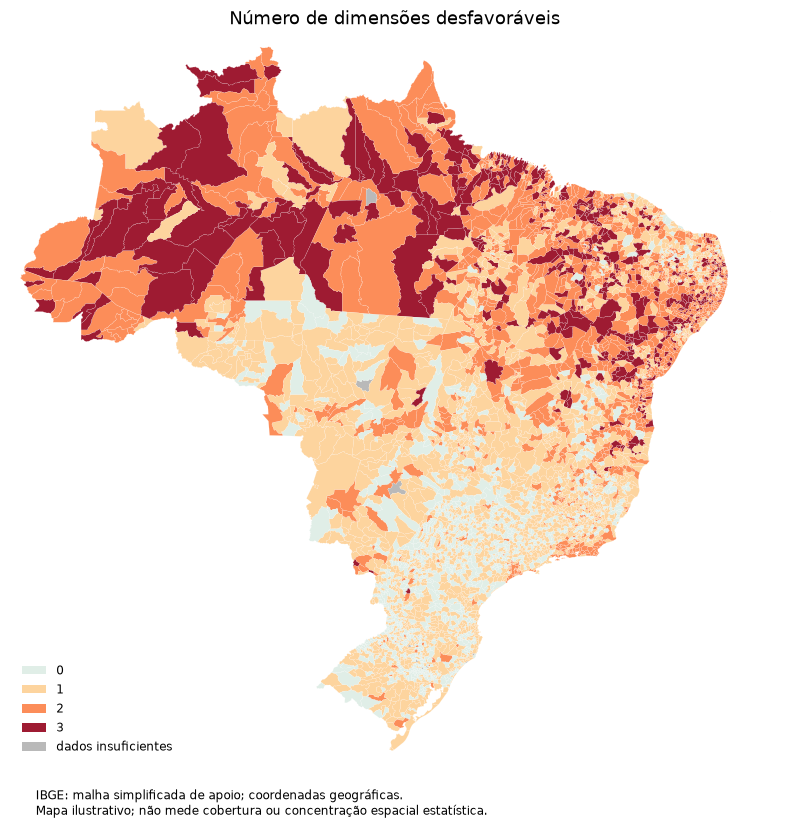

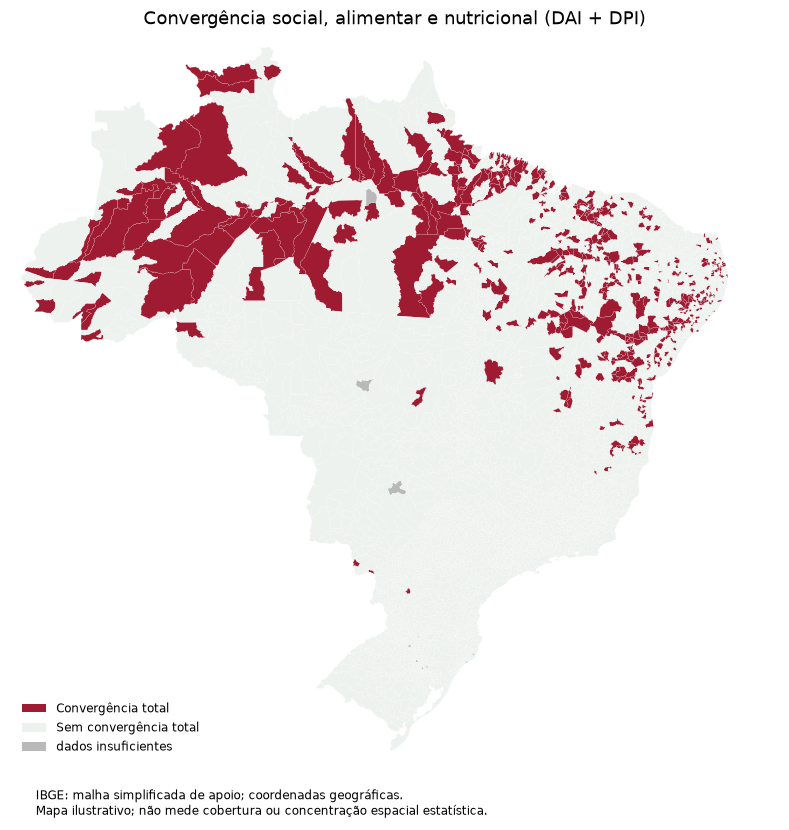

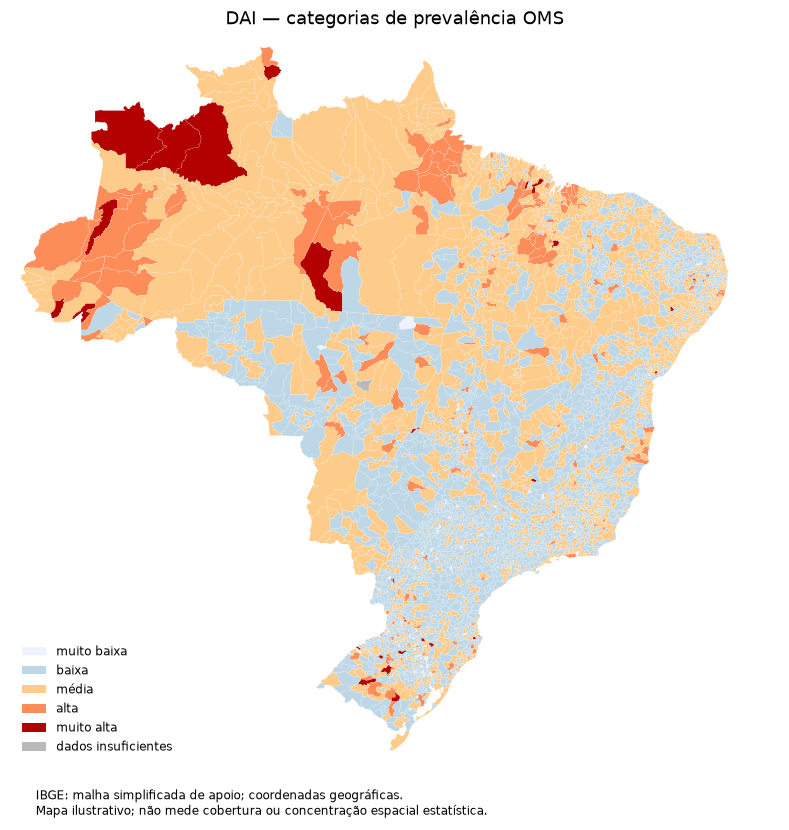

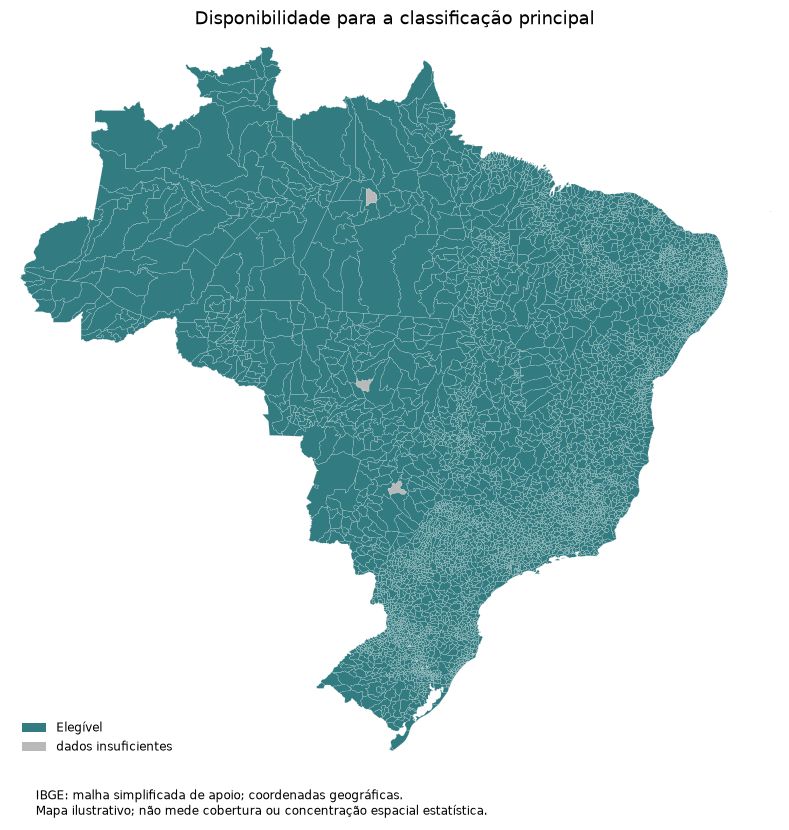

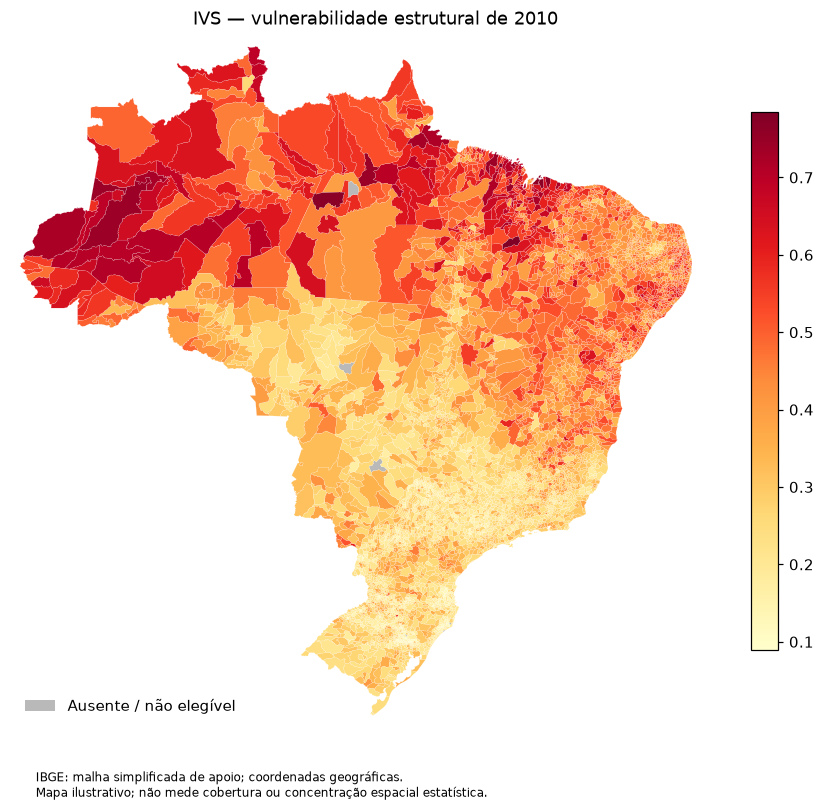

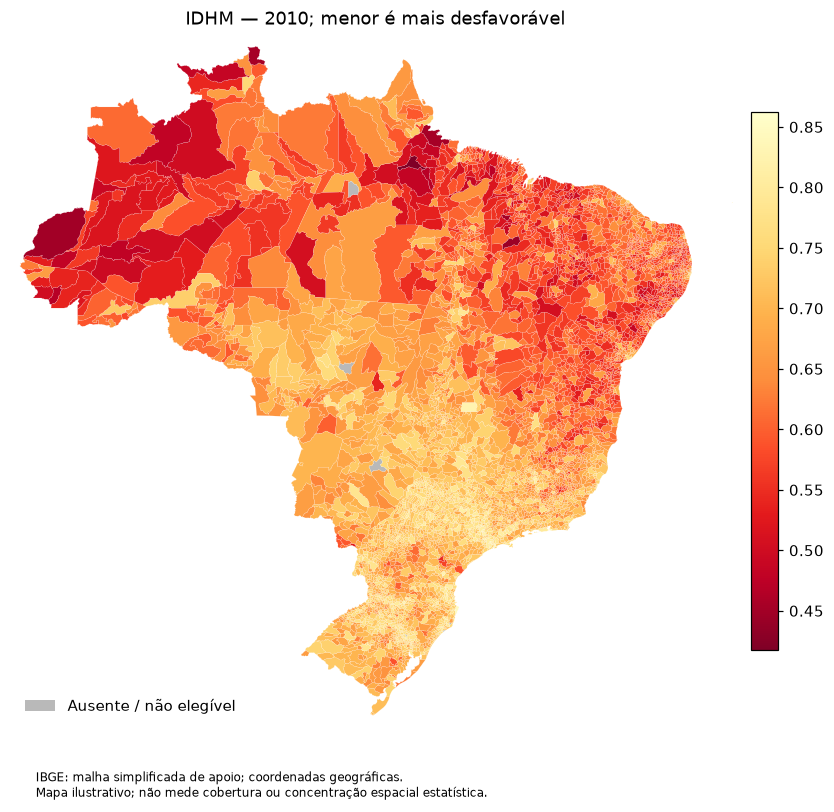

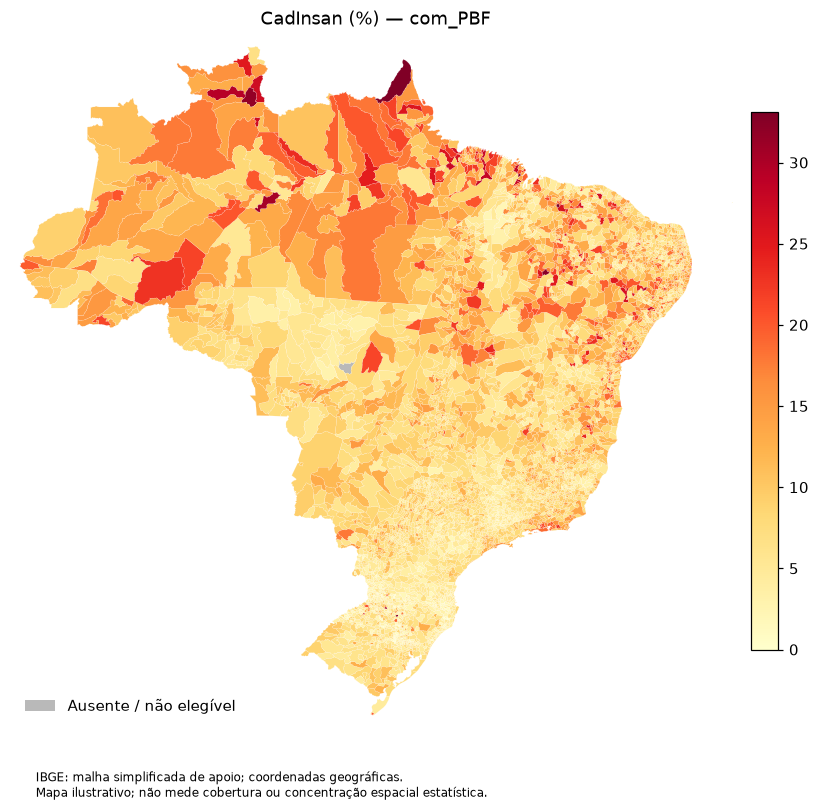

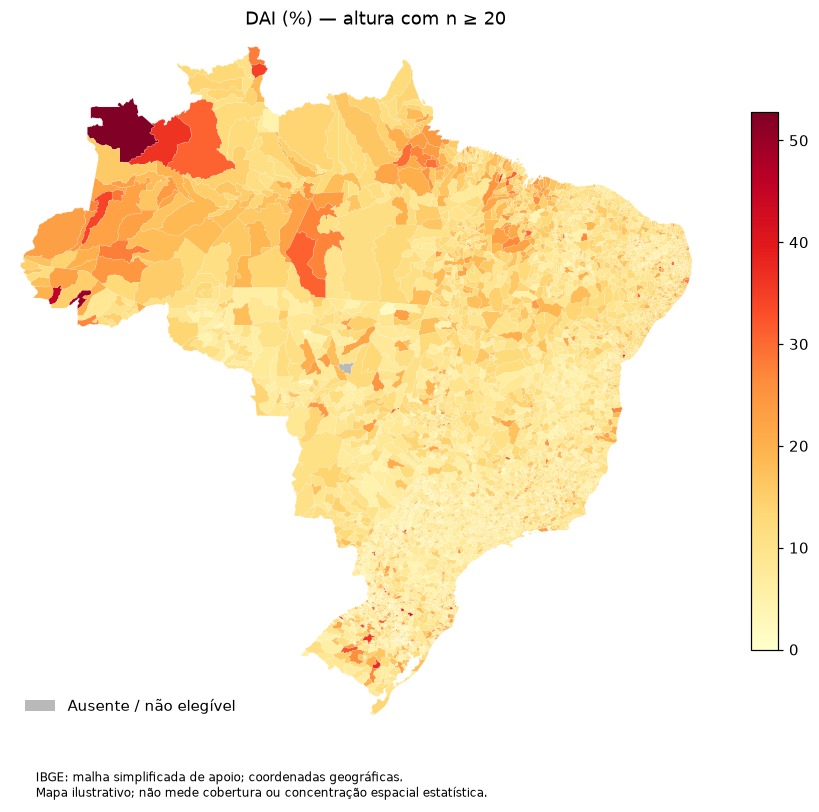

In [10]:
print("Municípios da análise sem geometria:", int((~controle_geometria["tem_geometria"]).sum()))
print("Feições sem registro na análise:", len(universo_ibge - set(base["codigo_ibge_6"])))
figuras_mapas = []
if GERAR_MAPAS:
    mapa = classificados.copy()
    mapa["dimensoes_mapa"] = mapa["n_dimensoes_desfavoraveis"].astype("string").fillna("dados insuficientes")
    mapa["convergencia_mapa"] = mapa["convergencia_total"].map(
        {True: "Convergência total", False: "Sem convergência total"}).fillna("dados insuficientes")
    mapa["disponibilidade"] = mapa["elegivel_principal"].map(
        {True: "Elegível", False: "dados insuficientes"})
    mapas_categoricos = [
        ("dimensoes_mapa", "Número de dimensões desfavoráveis", "09_dimensoes", DIMENSION_COLORS),
        ("convergencia_mapa", "Convergência social, alimentar e nutricional (DAI + DPI)", "11_convergencia_total",
            {"Convergência total": "#9e1b32", "Sem convergência total": "#edf2ef", "dados insuficientes": "#b9b9b9"}),
        ("dai_categoria_oms", "DAI — categorias de prevalência OMS", "12_dai_oms", OMS_COLORS),
        ("disponibilidade", "Disponibilidade para a classificação principal", "05_disponibilidade",
            {"Elegível": "#327c81", "dados insuficientes": "#b9b9b9"})]
    for coluna, titulo, nome, cores in mapas_categoricos:
        display(map_figure(geometria, mapa, coluna, titulo, PASTA_FIGURAS, nome, cores))
        figuras_mapas.append(nome)
        plt.close("all")
    for coluna, titulo, nome in [("ivs", "IVS — vulnerabilidade estrutural de 2010", "06_ivs"),
        ("idhm", "IDHM — 2010; menor é mais desfavorável", "10_idhm"),
        ("cadinsan_pct", f"CadInsan (%) — {CENARIO_CADINSAN}", "07_cadinsan"),
        ("dai_pct", f"DAI (%) — altura com n ≥ {MINIMO_AVALIADOS}", "08_dai")]:
        if coluna == "dai_pct":
            mapa[coluna] = mapa[coluna].where(mapa["avaliados_altura"].ge(MINIMO_AVALIADOS))
        display(map_figure(geometria, mapa, coluna, titulo, PASTA_FIGURAS, nome))
        figuras_mapas.append(nome)
        plt.close("all")

## 9. Sensibilidade e estabilidade

Repetimos a análise com outros cortes e mínimos de avaliações para verificar
quanto a seleção depende dessas escolhas. Comparamos as listas com o cenário
principal; as alternativas não substituem seu resultado.

<details>
<summary>Cenários testados e medidas de estabilidade</summary>

- CadInsan: P70, P75, P80 e P90.
- Mínimos por relatório SISVAN: 20, 50 e 100.
- DAI: 6,7% (Mapa InSAN), 10% (início da faixa OMS média) e P75 (exploratório).
- Renda: cenários com e sem efeito do PBF, não grupos de beneficiários.

IVS, IDHM e DPI ficam fixos. O P75 de DAI usa municípios acima do mínimo de altura;
os percentis CadInsan usam todos os municípios válidos, antes dos outros filtros,
sem ponderação populacional e incluindo empates no corte.

As tabelas isolam uma mudança por vez; a exportação inclui as 72 combinações.
Entradas e saídas são sempre relativas ao cenário principal.

Jaccard mede semelhança entre listas (interseção/união; 1 indica igualdade).
A frequência de seleção é a fração dos cenários testados, não probabilidade
de risco nem intervalo de confiança.

</details>

### CadInsan — uma mudança por vez

,cenario,quantil,minimo_avaliados,referencia_dai,corte_dai_pct,corte_cadinsan_pct,elegiveis,municipios_dim_alimentar,municipios_dim_nutricional,convergencia_total,corte_dpi_pct,entram_vs_principal,saem_vs_principal,coincidentes_principal,jaccard_principal
0,com_PBF,"0,70",20,6.7,"6,70%","10,16%",5.561,1.671,3.693,589,"1,80%",81,0,508,"0,862"
9,com_PBF,"0,75",20,6.7,"6,70%","10,97%",5.561,1.393,3.693,508,"1,80%",0,0,508,"1,000"
18,com_PBF,"0,80",20,6.7,"6,70%","11,92%",5.561,1.114,3.693,445,"1,80%",0,63,445,"0,876"
27,com_PBF,"0,90",20,6.7,"6,70%","14,97%",5.561,557,3.693,261,"1,80%",0,247,261,"0,514"


### Mínimo de avaliações — uma mudança por vez

,cenario,quantil,minimo_avaliados,referencia_dai,corte_dai_pct,corte_cadinsan_pct,elegiveis,municipios_dim_alimentar,municipios_dim_nutricional,convergencia_total,corte_dpi_pct,entram_vs_principal,saem_vs_principal,coincidentes_principal,jaccard_principal
9,com_PBF,"0,75",20,6.7,"6,70%","10,97%",5.561,1.393,3.693,508,"1,80%",0,0,508,"1,000"
12,com_PBF,"0,75",50,6.7,"6,70%","10,97%",5.531,1.393,3.684,508,"1,80%",0,0,508,"1,000"
15,com_PBF,"0,75",100,6.7,"6,70%","10,97%",5.326,1.393,3.613,507,"1,80%",0,1,507,"0,998"


### DAI — uma mudança por vez

,cenario,quantil,minimo_avaliados,referencia_dai,corte_dai_pct,corte_cadinsan_pct,elegiveis,municipios_dim_alimentar,municipios_dim_nutricional,convergencia_total,corte_dpi_pct,entram_vs_principal,saem_vs_principal,coincidentes_principal,jaccard_principal
9,com_PBF,"0,75",20,6.7,"6,70%","10,97%",5.561,1.393,3.693,508,"1,80%",0,0,508,"1,000"
10,com_PBF,"0,75",20,10.0,"10,00%","10,97%",5.561,1.393,2.253,373,"1,80%",0,135,373,"0,734"
11,com_PBF,"0,75",20,P75,"12,37%","10,97%",5.561,1.393,1.301,237,"1,80%",0,271,237,"0,467"


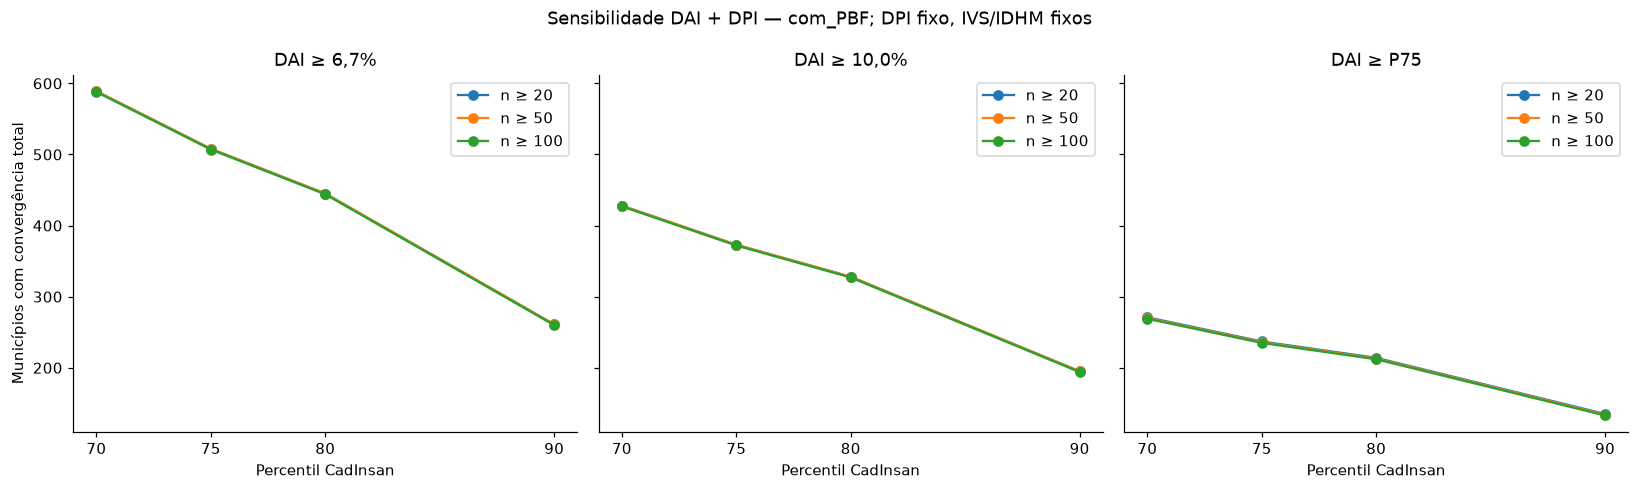

,municipio,uf,cenarios_elegiveis,cenarios_selecionado,cenarios_testados,fracao_cenarios_selecionado
53,ASSIS BRASIL,AC,72,63,72,"0,875"
62,MANOEL URBANO,AC,72,63,72,"0,875"
63,MARECHAL THAUMATURGO,AC,72,54,72,"0,750"
67,RODRIGUES ALVES,AC,72,63,72,"0,875"
68,SANTA ROSA DO PURUS,AC,72,27,72,"0,375"
1654,BARRA DE SANTO ANTONIO,AL,72,18,72,"0,250"
1668,CARNEIROS,AL,72,45,72,"0,625"
1669,CHA PRETA,AL,72,36,72,"0,500"
1671,COLONIA LEOPOLDINA,AL,72,27,72,"0,375"
1672,COQUEIRO SECO,AL,72,45,72,"0,625"


In [11]:
tabela_sensibilidade, estabilidade = sensitivity(
    base, classificados, sorted(set(QUANTIS_SENSIBILIDADE + [QUANTIL_CADINSAN])),
    sorted(set(MINIMOS_SENSIBILIDADE + [MINIMO_AVALIADOS])),
    sorted(set(CENARIOS_SENSIBILIDADE + [CENARIO_CADINSAN])),
    list(dict.fromkeys(CORTES_DAI_SENSIBILIDADE + [CORTE_DAI])), CORTE_DPI)
principal_sens = tabela_sensibilidade["cenario"].eq(CENARIO_CADINSAN)
sensibilidade_cadinsan = tabela_sensibilidade.loc[principal_sens &
    tabela_sensibilidade["minimo_avaliados"].eq(MINIMO_AVALIADOS) &
    tabela_sensibilidade["referencia_dai"].eq(str(CORTE_DAI))]
sensibilidade_minimos = tabela_sensibilidade.loc[principal_sens &
    tabela_sensibilidade["quantil"].eq(QUANTIL_CADINSAN) &
    tabela_sensibilidade["referencia_dai"].eq(str(CORTE_DAI))]
sensibilidade_dai = tabela_sensibilidade.loc[principal_sens &
    tabela_sensibilidade["quantil"].eq(QUANTIL_CADINSAN) &
    tabela_sensibilidade["minimo_avaliados"].eq(MINIMO_AVALIADOS)]
for titulo, tabela in [("CadInsan — uma mudança por vez", sensibilidade_cadinsan),
                       ("Mínimo de avaliações — uma mudança por vez", sensibilidade_minimos),
                       ("DAI — uma mudança por vez", sensibilidade_dai)]:
    display(Markdown("### " + titulo))
    display(tabela_br(tabela))
display(sensitivity_figure(tabela_sensibilidade, PASTA_FIGURAS, CENARIO_CADINSAN))
plt.close("all")
classificados = classificados.merge(estabilidade, on="codigo_ibge_6", validate="one_to_one")
convergentes = classificados.loc[classificados["convergencia_total"].fillna(False)].sort_values(["uf", "municipio"])
display(tabela_br(convergentes[["municipio", "uf", "cenarios_elegiveis", "cenarios_selecionado",
    "cenarios_testados", "fracao_cenarios_selecionado"]].head(30)))

## 10. Limitações

- **Períodos distintos:** IVS/IDHM são de 2010; CadInsan e SISVAN, de 2025.
- **Populações específicas:** SISVAN descreve crianças acompanhadas, não necessariamente todas as residentes; CadInsan estima risco entre famílias do universo cadastrado.
- **Denominadores:** altura e peso não identificam necessariamente as mesmas crianças. A conjunção dos déficits é municipal, não individual; o mínimo de avaliações não garante precisão.
- **Território:** códigos correspondentes não asseguram limites históricos equivalentes. A malha sem ano informado é apoio ilustrativo, sem análise espacial formal.
- **Interpretação:** a sobreposição não demonstra causalidade. As classes são exploratórias, não um diagnóstico de fome, e não substituem investigação local; dados insuficientes não significam baixo risco.

## 11. Síntese dos resultados

A síntese abaixo é gerada a partir desta execução e destaca a concentração
territorial dos municípios selecionados.

In [12]:
selecionados = len(convergentes)
# Empates regionais são preservados: não se escolhe arbitrariamente uma região.
max_absoluto = resumo_regional["convergencia_total"].max()
max_proporcao = resumo_regional["pct_convergencia_elegiveis"].max()
regioes_absoluto = ", ".join(resumo_regional.loc[resumo_regional["convergencia_total"].eq(max_absoluto), "regiao"])
regioes_proporcao = ", ".join(resumo_regional.loc[resumo_regional["pct_convergencia_elegiveis"].eq(max_proporcao), "regiao"])
linhas_regionais = "\n".join(
    f"- {r.regiao}: {contagem_br(r.convergencia_total)} de {contagem_br(r.elegiveis)} elegíveis "
    f"({percentual_br(r.pct_convergencia_elegiveis)})." for r in resumo_regional.itertuples())
def descrever_cenarios(tabela, parametro):
    def rotulo(valor):
        if parametro == "quantil":
            return f"P{valor * 100:.0f}"
        if parametro == "referencia_dai":
            return "P75" if valor == "P75" else numero_br(float(valor), 1) + "%"
        return f"n ≥ {valor}"
    return "; ".join(f"{rotulo(getattr(r, parametro))} → {contagem_br(r.convergencia_total)}" for r in tabela.itertuples())
def amplitude(tabela):
    return int(tabela["convergencia_total"].max() - tabela["convergencia_total"].min())
amplitudes = {"mínimo SISVAN": amplitude(sensibilidade_minimos),
              "quantil CadInsan": amplitude(sensibilidade_cadinsan),
              "componente DAI": amplitude(sensibilidade_dai)}
maior_amplitude = max(amplitudes.values())
menor_amplitude = min(amplitudes.values())
parametros_maior = ", ".join(k for k, v in amplitudes.items() if v == maior_amplitude)
parametros_menor = ", ".join(k for k, v in amplitudes.items() if v == menor_amplitude)
mudanca_maxima_minimo = max(
    sensibilidade_minimos["entram_vs_principal"].max(),
    sensibilidade_minimos["saem_vs_principal"].max())
interpretacao_minimos = (
    f"Maior número de entradas/saídas em relação ao cenário principal: {contagem_br(mudanca_maxima_minimo)} "
    f"(seleção principal: {contagem_br(selecionados)} unidades). "
    "Isso não demonstra precisão ou representatividade das estimativas."
)
if amplitudes["mínimo SISVAN"] < min(amplitudes["quantil CadInsan"], amplitudes["componente DAI"]):
    interpretacao_minimos += " A classificação mostrou-se comparativamente pouco sensível ao mínimo entre 20 e 100 neste conjunto."
resumo_execucao = f"""# Síntese da análise municipal

**Universo:** {contagem_br(len(base))} unidades municipais; **{contagem_br(elegiveis)} avaliáveis**
nas três dimensões principais e **{contagem_br(len(base) - elegiveis)} com dados insuficientes**.
As contagens de cada dimensão entre todos os classificáveis nela são:
**social {contagem_br(int(classificados['dim_social'].sum()))}**,
**alimentar {contagem_br(int(classificados['dim_alimentar'].sum()))}** e
**nutricional DAI + DPI {contagem_br(int(classificados['dim_nutricional'].sum()))}**.
Esses universos dimensionais podem diferir; no universo comum de elegíveis,
as contagens são, respectivamente,
{contagem_br(int(classificados.loc[classificados.elegivel_principal, 'dim_social'].sum()))},
{contagem_br(int(classificados.loc[classificados.elegivel_principal, 'dim_alimentar'].sum()))} e
{contagem_br(int(classificados.loc[classificados.elegivel_principal, 'dim_nutricional'].sum()))}.

**Convergência principal: {contagem_br(selecionados)} unidades**, ou
**{percentual_br(selecionados / elegiveis * 100 if elegiveis else np.nan)} dos elegíveis**;
{percentual_br(selecionados_na_malha / len(universo_ibge) * 100)} da malha IBGE incorporada.
Esses municípios apresentam convergência dos indicadores desfavoráveis segundo
os critérios adotados, não constituem um ranking dos mais vulneráveis do Brasil.
Regra: IVS ≥0,401 E IDHM <0,600; CadInsan ≥P{QUANTIL_CADINSAN * 100:.0f}
({CENARIO_CADINSAN}); DAI ≥{numero_br(CORTE_DAI, 1)}% E DPI ≥{numero_br(CORTE_DPI, 1)}%,
com ≥{MINIMO_AVALIADOS} avaliações em cada relatório.

**Distribuição regional — convergência / elegíveis da própria região:**

{linhas_regionais}

A maior concentração absoluta está em **{regioes_absoluto}**
({contagem_br(max_absoluto)} unidades); a maior proporção entre elegíveis
está em **{regioes_proporcao}** ({percentual_br(max_proporcao)}).
Prevalência regional da classificação municipal não equivale à prevalência
de fome nas pessoas; concentração absoluta e proporção têm denominadores distintos.

**Sensibilidade — uma mudança por vez, mantendo os demais parâmetros principais:**

- Mínimo SISVAN (altura e peso): {descrever_cenarios(sensibilidade_minimos, 'minimo_avaliados')}.
  {interpretacao_minimos}
- CadInsan: {descrever_cenarios(sensibilidade_cadinsan, 'quantil')}.
  Amplitude de {contagem_br(amplitudes['quantil CadInsan'])} unidades; P75 não é corte oficial.
- DAI: {descrever_cenarios(sensibilidade_dai, 'referencia_dai')}.
  Amplitude de {contagem_br(amplitudes['componente DAI'])} unidades, mantendo DPI fixo.
  6,7% é referência Mapa InSAN, 10% inicia categoria OMS média, P75 é distributivo.

Nos intervalos testados, **{parametros_menor}** tem menor amplitude
({contagem_br(menor_amplitude)}), e **{parametros_maior}** tem maior
({contagem_br(maior_amplitude)}). Trata-se de dependência nos cenários escolhidos,
não de uma medida universal de importância. As listas e entradas/saídas
mostram quais conclusões resistem a cada mudança; o total isolado não basta.
As {len(tabela_sensibilidade)} combinações variam entre
{contagem_br(tabela_sensibilidade.convergencia_total.min())} e
{contagem_br(tabela_sensibilidade.convergencia_total.max())}; essa amplitude é
secundária e não é intervalo de confiança.

**Limitações centrais:** dimensão social histórica (2010), fontes alimentares e
nutricionais de 2025, população SISVAN não necessariamente representativa,
variabilidade dos denominadores, P75 exploratório e ausência de ligação
individual altura/peso. DAI e DPI não esgotam a insegurança alimentar.
Os {contagem_br(len(municipios_sem_ivs_idhm))} casos sem IVS/IDHM são listados
com fontes oficiais; não se imputam índices históricos de municípios de origem.
Validar a interpretação científica dessas escolhas com o orientador antes de
extrapolar os resultados a toda a população ou usá-los para recomendação de políticas.
"""
# Remove indentação de apresentação sem alterar cálculos ou valores exportados.
resumo_execucao = "\n".join(line[4:] if line.startswith("    ") else line for line in resumo_execucao.splitlines())
display(Markdown(resumo_execucao))

# Síntese da análise municipal

**Universo:** 5.571 unidades municipais; **5.561 avaliáveis**
nas três dimensões principais e **10 com dados insuficientes**.
As contagens de cada dimensão entre todos os classificáveis nela são:
**social 1.302**,
**alimentar 1.393** e
**nutricional DAI + DPI 3.693**.
Esses universos dimensionais podem diferir; no universo comum de elegíveis,
as contagens são, respectivamente,
1.302,
1.391 e
3.690.

**Convergência principal: 508 unidades**, ou
**9,14% dos elegíveis**;
9,12% da malha IBGE incorporada.
Esses municípios apresentam convergência dos indicadores desfavoráveis segundo
os critérios adotados, não constituem um ranking dos mais vulneráveis do Brasil.
Regra: IVS ≥0,401 E IDHM <0,600; CadInsan ≥P75
(com_PBF); DAI ≥6,7% E DPI ≥1,8%,
com ≥20 avaliações em cada relatório.

**Distribuição regional — convergência / elegíveis da própria região:**

- Centro-Oeste: 3 de 466 elegíveis (0,64%).
- Nordeste: 371 de 1.794 elegíveis (20,68%).
- Norte: 123 de 449 elegíveis (27,39%).
- Sudeste: 10 de 1.668 elegíveis (0,60%).
- Sul: 1 de 1.184 elegíveis (0,08%).

A maior concentração absoluta está em **Nordeste**
(371 unidades); a maior proporção entre elegíveis
está em **Norte** (27,39%).
Prevalência regional da classificação municipal não equivale à prevalência
de fome nas pessoas; concentração absoluta e proporção têm denominadores distintos.

**Sensibilidade — uma mudança por vez, mantendo os demais parâmetros principais:**

- Mínimo SISVAN (altura e peso): n ≥ 20 → 508; n ≥ 50 → 508; n ≥ 100 → 507.
  Maior número de entradas/saídas em relação ao cenário principal: 1 (seleção principal: 508 unidades). Isso não demonstra precisão ou representatividade das estimativas. A classificação mostrou-se comparativamente pouco sensível ao mínimo entre 20 e 100 neste conjunto.
- CadInsan: P70 → 589; P75 → 508; P80 → 445; P90 → 261.
  Amplitude de 328 unidades; P75 não é corte oficial.
- DAI: 6,7% → 508; 10,0% → 373; P75 → 237.
  Amplitude de 271 unidades, mantendo DPI fixo.
  6,7% é referência Mapa InSAN, 10% inicia categoria OMS média, P75 é distributivo.

Nos intervalos testados, **mínimo SISVAN** tem menor amplitude
(1), e **quantil CadInsan** tem maior
(328). Trata-se de dependência nos cenários escolhidos,
não de uma medida universal de importância. As listas e entradas/saídas
mostram quais conclusões resistem a cada mudança; o total isolado não basta.
As 72 combinações variam entre
133 e
627; essa amplitude é
secundária e não é intervalo de confiança.

**Limitações centrais:** dimensão social histórica (2010), fontes alimentares e
nutricionais de 2025, população SISVAN não necessariamente representativa,
variabilidade dos denominadores, P75 exploratório e ausência de ligação
individual altura/peso. DAI e DPI não esgotam a insegurança alimentar.
Os 6 casos sem IVS/IDHM são listados
com fontes oficiais; não se imputam índices históricos de municípios de origem.
Validar a interpretação científica dessas escolhas com o orientador antes de
extrapolar os resultados a toda a população ou usá-los para recomendação de políticas.

## 12. Exportação dos resultados

O ZIP reúne a base municipal, listas de convergência, tabelas, figuras,
dicionário, síntese e manifesto da execução.
Baixe-o pela aba de arquivos do Colab ou ative a opção nos parâmetros.

<details>
<summary>Conteúdo e rastreabilidade</summary>

A base completa inclui dados insuficientes. São exportadas também as auditorias,
categorias de DAI e sensibilidade.
As figuras são salvas em PNG/SVG.

O manifesto registra parâmetros, fórmulas, procedência, hashes das entradas
e do código de análise e versões do ambiente.

</details>

In [13]:
identificador = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
destino = PASTA_SAIDA / f"execucao_{identificador}"
destino.mkdir()
tabelas = {"base_municipal_final": classificados, "municipios_sem_ivs_idhm": municipios_sem_ivs_idhm, "municipios_convergencia_total": convergentes,
    "cortes": cortes, "controle_integracao": controle_integracao, "municipios_sem_correspondencia": ausencias,
    "sem_classificacao": sem_classificacao, "qualidade_sisvan": qualidade_sisvan,
    "interpretacao_sisvan": interpretacao_sisvan, "controle_geometria": controle_geometria,
    "descritivas": descritivas.rename_axis("indicador").reset_index(), "totais_nutricionais": totais_nutricionais,
    "resumo_nacional": resumo_nacional, "resumo_uf": resumo_uf, "resumo_regional": resumo_regional,
    "resumo_classes": resumo_classes, "resumo_social": resumo_social, "resumo_oms": resumo_oms,
    "peso_insuficiente": peso_insuficiente,
    "sensibilidade": tabela_sensibilidade, "sensibilidade_cadinsan": sensibilidade_cadinsan,
    "sensibilidade_minimos": sensibilidade_minimos, "sensibilidade_dai": sensibilidade_dai,
    "estabilidade": estabilidade, "dicionario_variaveis": dictionary(), "validacao_catalogo": validacao_catalogo}
for nome, tabela in tabelas.items():
    tabela.to_csv(destino / f"{nome}.csv", index=False, encoding="utf-8-sig")
(destino / "figuras").mkdir()
for nome in ["04_sensibilidade"] + figuras_mapas:
    for extensao in ["png", "svg"]:
        shutil.copy2(PASTA_FIGURAS / f"{nome}.{extensao}", destino / "figuras")
manifesto = {
    "experimento": "sobreposicao_criterios", "executado_em": datetime.now(timezone.utc).isoformat(),
    "quantil_cadinsan": QUANTIL_CADINSAN, "corte_dai_pct": CORTE_DAI,
    "corte_dpi_pct": CORTE_DPI, "minimo_avaliados": MINIMO_AVALIADOS,
    "cenario_cadinsan": CENARIO_CADINSAN,
    "formula_cadinsan_pct": "100 * familias_risco_cenario / familias_cadinsan",
    "formula_dai_pct": "100 * (altura_muito_baixa_n + altura_baixa_n) / avaliados_altura",
    "formula_dpi_pct": "100 * (peso_muito_baixo_n + peso_baixo_n) / avaliados_peso",
    "dimensoes": {"social": "IVS >=0.401 E IDHM <0.600", "alimentar": "CadInsan >= quantil nacional",
                  "nutricional": "DAI >= corte E DPI >= corte E mínimos separados de altura e peso"},
    "regra": "Convergência das três dimensões; nutrição DAI + DPI",
    "indicadores_com_quantil_principal": ["cadinsan"], "cortes": json.loads(cortes.to_json(orient="records")),
    "hashes_entrada": hashes_entrada.to_dict("records"), "codigo_analise_sha256": CODIGO_ANALISE_SHA256,
    "proveniencia_catalogo": proveniencia_catalogo,
    "proveniencia_sisvan": {s: sisvan_metadata(PASTA_DADOS, s) for s in ["sisvan_altura", "sisvan_peso"]},
    "integridade_entradas": json.loads((PASTA_DADOS / "documentacao/manifesto_entradas.json").read_text()),
    "manifesto_entradas_sha256": hashlib.sha256((PASTA_DADOS / "SHA256SUMS").read_bytes()).hexdigest(),
    "ambiente_referencia": VERSOES_REFERENCIA, "divergencias_ambiente": divergencias_ambiente,
    "malha": metadados_malha, "universo_nacional": resumo_nacional.to_dict("records"),
    "ambiente": {"python": platform.python_version(), "pandas": pd.__version__, "numpy": np.__version__,
                 "matplotlib": matplotlib.__version__, "scipy": scipy.__version__},
    "sensibilidade": tabela_sensibilidade.to_dict("records"),
    "limites": ["Temporalidade 2010/2025", "Público SISVAN não necessariamente representativo",
                "Adaptação das referências nutricionais; não reprodução do Mapa InSAN",
                "Corte CadInsan exploratório", "Sem cobertura populacional ou inferência causal"]}
(destino / "manifesto_execucao.json").write_text(json.dumps(manifesto, ensure_ascii=False, indent=2, allow_nan=False) + "\n", encoding="utf-8")
(destino / "resumo.md").write_text(resumo_execucao, encoding="utf-8")
shutil.copytree(PASTA_DADOS / "documentacao", destino / "documentacao_entradas")
shutil.copy2(PASTA_DADOS / "README.md", destino / "documentacao_entradas/README_SELECAO.md")
shutil.copy2(PASTA_DADOS / "SHA256SUMS", destino / "documentacao_entradas")
arquivo_zip = shutil.make_archive(str(destino), "zip", root_dir=destino)
print("ZIP pronto:", Path(arquivo_zip).resolve().relative_to(Path.cwd()))
if BAIXAR_RESULTADOS_NO_COLAB:
    try:
        from google.colab import files
    except ImportError:
        print("Fora do Colab: utilizar o ZIP no caminho informado.")
    else:
        files.download(arquivo_zip)

ZIP pronto: resultados/resultados/execucao_20261007T012814455033Z.zip


## Referências

<details>
<summary>Fontes e referências metodológicas</summary>

- Ipea (2015). [Atlas da Vulnerabilidade Social](https://repositorio.ipea.gov.br/bitstream/11058/4381/1/Atlas_da_vulnerabilidade_social_nos_municipios_brasileiros.pdf).
- PNUD/Ipea/FJP. [Atlas do Desenvolvimento Humano](https://www.undp.org/pt/brazil/desenvolvimento-humano/atlas-do-desenvolvimento-humano-no-brasil); [faixas de IDHM](https://www.undp.org/sites/g/files/zskgke326/files/2024-05/anexo_estatistico_pnud_21maio24_isbn_web2.pdf).
- MDS. [CadInsan 2025](https://www.gov.br/mds/pt-br/Sisan/vigilancia-do-sisan/CADINSAN2025.pdf): universo (p. 7) e cenários (p. 16–19).
- Ministério da Saúde. [SISVAN — relatórios públicos](https://sisaps.saude.gov.br/sisvan/relatoriopublico/).
- MDS. [Mapa InSAN 2017–2022](https://aplicacoes.mds.gov.br/fomento-questionario/pdf/MapaInSAN_20172022.pdf#page=11): cortes e mínimo de acompanhamentos (p. 11, tabela 2).
- Ministério da Saúde (2009). [PNDS 2006](https://bvsms.saude.gov.br/bvs/publicacoes/pnds_crianca_mulher.pdf): prevalências de referência (p. 217, citada pelo Mapa InSAN).
- OMS. [Faixas de prevalência de baixa estatura](https://www.who.int/data/nutrition/nlis/info/malnutrition-in-children); [de Onis et al. (2018)](https://doi.org/10.1017/S1368980018002434).
- [Cozinhas Solidárias](https://github.com/TriangulosTecnologia/cozsolidarias): procedência dos CSVs sociais.
- IBGE. [API de malhas v4](https://servicodados.ibge.gov.br/api/docs/malhas?versao=4).
- IBGE. [MUNIC 2013](https://ftp.ibge.gov.br/Perfil_Municipios/2013/nota_tecnica2013.pdf): mudanças territoriais.
- IBGE. [Boa Esperança do Norte](https://educa.ibge.gov.br/criancas/voce-sabia/22741-novo-municipio.html): instalação em 2025.

</details>